Import Required Libraries

In [1]:
from pathlib import Path
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("✓ Libraries imported successfully.")

✓ Libraries imported successfully.


Dataset Path Configuration

In [2]:
from pathlib import Path

PROJECT_PATH = Path(r"E:\ML_Project")
DATASET_PATH = PROJECT_PATH / "datasets" / "bdd100k_original_yolo"

train_images = DATASET_PATH / "train" / "images"
valid_images = DATASET_PATH / "valid" / "images"
test_images  = DATASET_PATH / "test" / "images"

print("Project Path :", PROJECT_PATH)
print("Dataset Path :", DATASET_PATH)
print()
print("Train Images :", train_images)
print("Valid Images :", valid_images)
print("Test Images  :", test_images)

Project Path : E:\ML_Project
Dataset Path : E:\ML_Project\datasets\bdd100k_original_yolo

Train Images : E:\ML_Project\datasets\bdd100k_original_yolo\train\images
Valid Images : E:\ML_Project\datasets\bdd100k_original_yolo\valid\images
Test Images  : E:\ML_Project\datasets\bdd100k_original_yolo\test\images


Output Configuration

In [3]:
RESULTS_PATH = PROJECT_PATH / "results"
FIGURES_PATH = PROJECT_PATH / "figures"
RESULTS_PATH.mkdir(parents=True, exist_ok=True)
FIGURES_PATH.mkdir(parents=True, exist_ok=True)

print("✓ Output directories ready.")
print()
print("Results :", RESULTS_PATH)
print("Figures :", FIGURES_PATH)

✓ Output directories ready.

Results : E:\ML_Project\results
Figures : E:\ML_Project\figures


In [4]:
IQA_FEATURES = [
    "mean_brightness",
    "brightness_std",
    "rms_contrast",
    "laplacian_variance",
    "tenengrad",
    "entropy",
    "dark_pixel_ratio",
    "bright_pixel_ratio",
    "mean_saturation",
    "saturation_std",
    "colorfulness",
    "edge_density",
    "noise_proxy",
]

print("=" * 60)
print("IQA Feature Set")
print("=" * 60)

for i, feature in enumerate(IQA_FEATURES, start=1):
    print(f"{i:2d}. {feature}")

print("-" * 60)
print(f"Total Features : {len(IQA_FEATURES)}")

IQA Feature Set
 1. mean_brightness
 2. brightness_std
 3. rms_contrast
 4. laplacian_variance
 5. tenengrad
 6. entropy
 7. dark_pixel_ratio
 8. bright_pixel_ratio
 9. mean_saturation
10. saturation_std
11. colorfulness
12. edge_density
13. noise_proxy
------------------------------------------------------------
Total Features : 13


IQA Feature Extraction Function

In [5]:
def extract_iqa_features(image_path):
    """
    Extract no-reference image-condition features.

    Images are resized to 320 x 180 before feature
    calculation to provide consistent and efficient
    feature extraction across the dataset.
    """
    
    image = cv2.imread(str(image_path))

    if image is None:
        raise ValueError(f"Unable to read image: {image_path}")

    image = cv2.resize(
        image,
        (320, 180),
        interpolation=cv2.INTER_AREA
    )
    gray = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2GRAY
    )
    gray_float = gray.astype(np.float32)
    mean_brightness = float(
        np.mean(gray_float)
    )
    brightness_std = float(
        np.std(gray_float)
    )
    rms_contrast = float(
        np.sqrt(np.mean(
            (gray_float - mean_brightness) ** 2
        ))
    )
    laplacian = cv2.Laplacian(
        gray,
        cv2.CV_64F
    )
    laplacian_variance = float(
        laplacian.var()
    )
    sobel_x = cv2.Sobel(
        gray,
        cv2.CV_64F,
        1,
        0,
        ksize=3
    )
    sobel_y = cv2.Sobel(
        gray,
        cv2.CV_64F,
        0,
        1,
        ksize=3
    )
    tenengrad = float(
        np.mean(
            sobel_x ** 2 +
            sobel_y ** 2
        )
    )
    histogram = np.bincount(
        gray.ravel(),
        minlength=256
    ).astype(np.float64)
    probabilities = histogram / histogram.sum()
    probabilities = probabilities[
        probabilities > 0
    ]
    entropy = float(
        -np.sum(
            probabilities *
            np.log2(probabilities)
        )
    )
    dark_pixel_ratio = float(
        np.mean(gray < 40)
    )
    bright_pixel_ratio = float(
        np.mean(gray > 215)
    )
    hsv = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2HSV
    )

    saturation = hsv[:, :, 1].astype(
        np.float32
    )
    mean_saturation = float(
        np.mean(saturation)
    )
    saturation_std = float(
        np.std(saturation)
    )
    b, g, r = cv2.split(
        image.astype(np.float32)
    )
    rg = np.abs(r - g)
    yb = np.abs(
        0.5 * (r + g) - b
    )
    colorfulness = float(
        np.sqrt(
            np.std(rg) ** 2 +
            np.std(yb) ** 2
        )
        +
        0.3 * np.sqrt(
            np.mean(rg) ** 2 +
            np.mean(yb) ** 2
        )
    )
    edges = cv2.Canny(
        gray,
        threshold1=100,
        threshold2=200
    )

    edge_density = float(
        np.mean(edges > 0)
    )
    median_image = cv2.medianBlur(
        gray,
        3
    )
    residual = (
        gray_float -
        median_image.astype(np.float32)
    )

    noise_proxy = float(
        np.std(residual)
    )

    return {
        "mean_brightness": mean_brightness,
        "brightness_std": brightness_std,
        "rms_contrast": rms_contrast,
        "laplacian_variance": laplacian_variance,
        "tenengrad": tenengrad,
        "entropy": entropy,
        "dark_pixel_ratio": dark_pixel_ratio,
        "bright_pixel_ratio": bright_pixel_ratio,
        "mean_saturation": mean_saturation,
        "saturation_std": saturation_std,
        "colorfulness": colorfulness,
        "edge_density": edge_density,
        "noise_proxy": noise_proxy,
    }

print("✓ IQA feature extraction function defined.")

✓ IQA feature extraction function defined.


Test Feature Extraction

In [6]:
sample_image = next(
    train_images.glob("*.jpg")
)

sample_features = extract_iqa_features(
    sample_image
)

print("=" * 60)
print("IQA Feature Extraction Test")
print("=" * 60)
print("Image :", sample_image.name)
print()

for feature, value in sample_features.items():
    print(f"{feature:<25}: {value:.6f}")

print()
print("✓ Single-image IQA extraction successful.")

IQA Feature Extraction Test
Image : 0000f77c-6257be58.jpg

mean_brightness          : 107.699135
brightness_std           : 61.733376
rms_contrast             : 61.733376
laplacian_variance       : 1588.679429
tenengrad                : 24967.024792
entropy                  : 7.557496
dark_pixel_ratio         : 0.159080
bright_pixel_ratio       : 0.060312
mean_saturation          : 63.106300
saturation_std           : 29.353676
colorfulness             : 31.869825
edge_density             : 0.122587
noise_proxy              : 8.119685

✓ Single-image IQA extraction successful.


Extraction Function for a Dataset Split. Instead of writing three nearly identical loops, we'll make one reusable function.

In [7]:
def extract_split_features(
    image_dir,
    split_name,
    output_file,
    checkpoint_interval=1000
):
    """
    Extract IQA features for all images in a dataset split.

    Results are periodically saved so that progress is not
    lost during long-running extraction.
    """
    image_files = sorted(
        image_dir.glob("*.jpg")
    )
    records = []
    total = len(image_files)

    print("=" * 70)
    print(f"IQA Extraction: {split_name.upper()}")
    print("=" * 70)
    print(f"Images to process : {total:,}")
    print()

    for index, image_path in enumerate(
        image_files,
        start=1
    ):
        try:

            features = extract_iqa_features(
                image_path
            )
            record = {
                "image_name": image_path.name,
                "image_path": str(image_path),
                "split": split_name,
            }

            record.update(features)
            records.append(record)

        except Exception as error:

            print(
                f"[WARNING] Failed: "
                f"{image_path.name} | {error}"
            )

        if index % checkpoint_interval == 0:

            print(
                f"Processed "
                f"{index:,}/{total:,} "
                f"({index / total * 100:.2f}%)"
            )
            checkpoint_df = pd.DataFrame(
                records
            )
            checkpoint_df.to_csv(
                output_file,
                index=False
            )

    result_df = pd.DataFrame(
        records
    )
    result_df.to_csv(
        output_file,
        index=False
    )

    print()
    print(
        f"✓ {split_name.upper()} extraction completed."
    )
    print(
        f"Records saved : {len(result_df):,}"
    )
    print(
        f"Output        : {output_file}"
    )

    return result_df

Training IQA Extraction

In [8]:
train_iqa_file = (
    RESULTS_PATH /
    "iqa_features_train.csv"
)

train_iqa = extract_split_features(
    image_dir=train_images,
    split_name="train",
    output_file=train_iqa_file,
    checkpoint_interval=1000
)

IQA Extraction: TRAIN
Images to process : 70,000

Processed 1,000/70,000 (1.43%)
Processed 2,000/70,000 (2.86%)
Processed 3,000/70,000 (4.29%)
Processed 4,000/70,000 (5.71%)
Processed 5,000/70,000 (7.14%)
Processed 6,000/70,000 (8.57%)
Processed 7,000/70,000 (10.00%)
Processed 8,000/70,000 (11.43%)
Processed 9,000/70,000 (12.86%)
Processed 10,000/70,000 (14.29%)
Processed 11,000/70,000 (15.71%)
Processed 12,000/70,000 (17.14%)
Processed 13,000/70,000 (18.57%)
Processed 14,000/70,000 (20.00%)
Processed 15,000/70,000 (21.43%)
Processed 16,000/70,000 (22.86%)
Processed 17,000/70,000 (24.29%)
Processed 18,000/70,000 (25.71%)
Processed 19,000/70,000 (27.14%)
Processed 20,000/70,000 (28.57%)
Processed 21,000/70,000 (30.00%)
Processed 22,000/70,000 (31.43%)
Processed 23,000/70,000 (32.86%)
Processed 24,000/70,000 (34.29%)
Processed 25,000/70,000 (35.71%)
Processed 26,000/70,000 (37.14%)
Processed 27,000/70,000 (38.57%)
Processed 28,000/70,000 (40.00%)
Processed 29,000/70,000 (41.43%)
Processe

Validation IQA Extraction

In [9]:
valid_iqa_file = (
    RESULTS_PATH /
    "iqa_features_valid.csv"
)

valid_iqa = extract_split_features(
    image_dir=valid_images,
    split_name="valid",
    output_file=valid_iqa_file,
    checkpoint_interval=1000
)

IQA Extraction: VALID
Images to process : 10,000

Processed 1,000/10,000 (10.00%)
Processed 2,000/10,000 (20.00%)
Processed 3,000/10,000 (30.00%)
Processed 4,000/10,000 (40.00%)
Processed 5,000/10,000 (50.00%)
Processed 6,000/10,000 (60.00%)
Processed 7,000/10,000 (70.00%)
Processed 8,000/10,000 (80.00%)
Processed 9,000/10,000 (90.00%)
Processed 10,000/10,000 (100.00%)

✓ VALID extraction completed.
Records saved : 10,000
Output        : E:\ML_Project\results\iqa_features_valid.csv


Test IQA Extraction

In [10]:
test_iqa_file = (
    RESULTS_PATH /
    "iqa_features_test.csv"
)

test_iqa = extract_split_features(
    image_dir=test_images,
    split_name="test",
    output_file=test_iqa_file,
    checkpoint_interval=1000
)

IQA Extraction: TEST
Images to process : 20,000

Processed 1,000/20,000 (5.00%)
Processed 2,000/20,000 (10.00%)
Processed 3,000/20,000 (15.00%)
Processed 4,000/20,000 (20.00%)
Processed 5,000/20,000 (25.00%)
Processed 6,000/20,000 (30.00%)
Processed 7,000/20,000 (35.00%)
Processed 8,000/20,000 (40.00%)
Processed 9,000/20,000 (45.00%)
Processed 10,000/20,000 (50.00%)
Processed 11,000/20,000 (55.00%)
Processed 12,000/20,000 (60.00%)
Processed 13,000/20,000 (65.00%)
Processed 14,000/20,000 (70.00%)
Processed 15,000/20,000 (75.00%)
Processed 16,000/20,000 (80.00%)
Processed 17,000/20,000 (85.00%)
Processed 18,000/20,000 (90.00%)
Processed 19,000/20,000 (95.00%)
Processed 20,000/20,000 (100.00%)

✓ TEST extraction completed.
Records saved : 20,000
Output        : E:\ML_Project\results\iqa_features_test.csv


Combine All IQA Features

In [11]:
iqa_features = pd.concat(
    [
        train_iqa,
        valid_iqa,
        test_iqa
    ],
    ignore_index=True
)

print("=" * 60)
print("Combined IQA Feature Dataset")
print("=" * 60)

print(f"Total Images : {len(iqa_features):,}")
print(f"Total Features : {len(IQA_FEATURES)}")

print()

print("Split Distribution")

print(
    iqa_features["split"]
    .value_counts()
)

print()

print("✓ IQA feature tables combined successfully.")

Combined IQA Feature Dataset
Total Images : 100,000
Total Features : 13

Split Distribution
split
train    70000
test     20000
valid    10000
Name: count, dtype: int64

✓ IQA feature tables combined successfully.


IQA Feature Validation

In [12]:
feature_columns = IQA_FEATURES

nan_counts = (
    iqa_features[feature_columns]
    .isna()
    .sum()
)

infinite_counts = np.isinf(
    iqa_features[feature_columns]
).sum()

print("=" * 60)
print("IQA Feature Validation")
print("=" * 60)

print(
    f"NaN Values      : "
    f"{nan_counts.sum():,}"
)

print(
    f"Infinite Values : "
    f"{infinite_counts.sum():,}"
)

print()

print("Feature Range Check")
print("-" * 60)

for feature in feature_columns:

    minimum = iqa_features[feature].min()
    maximum = iqa_features[feature].max()

    print(
        f"{feature:<25} "
        f"Min: {minimum:.6f} | "
        f"Max: {maximum:.6f}"
    )

print()

if (
    nan_counts.sum() == 0
    and infinite_counts.sum() == 0
):

    print(
        "✓ IQA feature validation passed."
    )

else:

    print(
        "✗ IQA feature validation failed."
    )

IQA Feature Validation
NaN Values      : 0
Infinite Values : 0

Feature Range Check
------------------------------------------------------------
mean_brightness           Min: 0.122344 | Max: 249.969025
brightness_std            Min: 1.889246 | Max: 93.578575
rms_contrast              Min: 1.889246 | Max: 93.578575
laplacian_variance        Min: 12.621545 | Max: 15744.091008
tenengrad                 Min: 107.504028 | Max: 84731.387917
entropy                   Min: 0.254857 | Max: 7.928956
dark_pixel_ratio          Min: 0.000000 | Max: 0.999618
bright_pixel_ratio        Min: 0.000000 | Max: 0.959010
mean_saturation           Min: 4.878819 | Max: 238.166687
saturation_std            Min: 7.736240 | Max: 122.537445
colorfulness              Min: 1.414865 | Max: 137.576965
edge_density              Min: 0.000729 | Max: 0.290729
noise_proxy               Min: 0.900676 | Max: 33.911674

✓ IQA feature validation passed.


IQA Feature Distributions. We'll create individual figures, rather than one giant subplot.

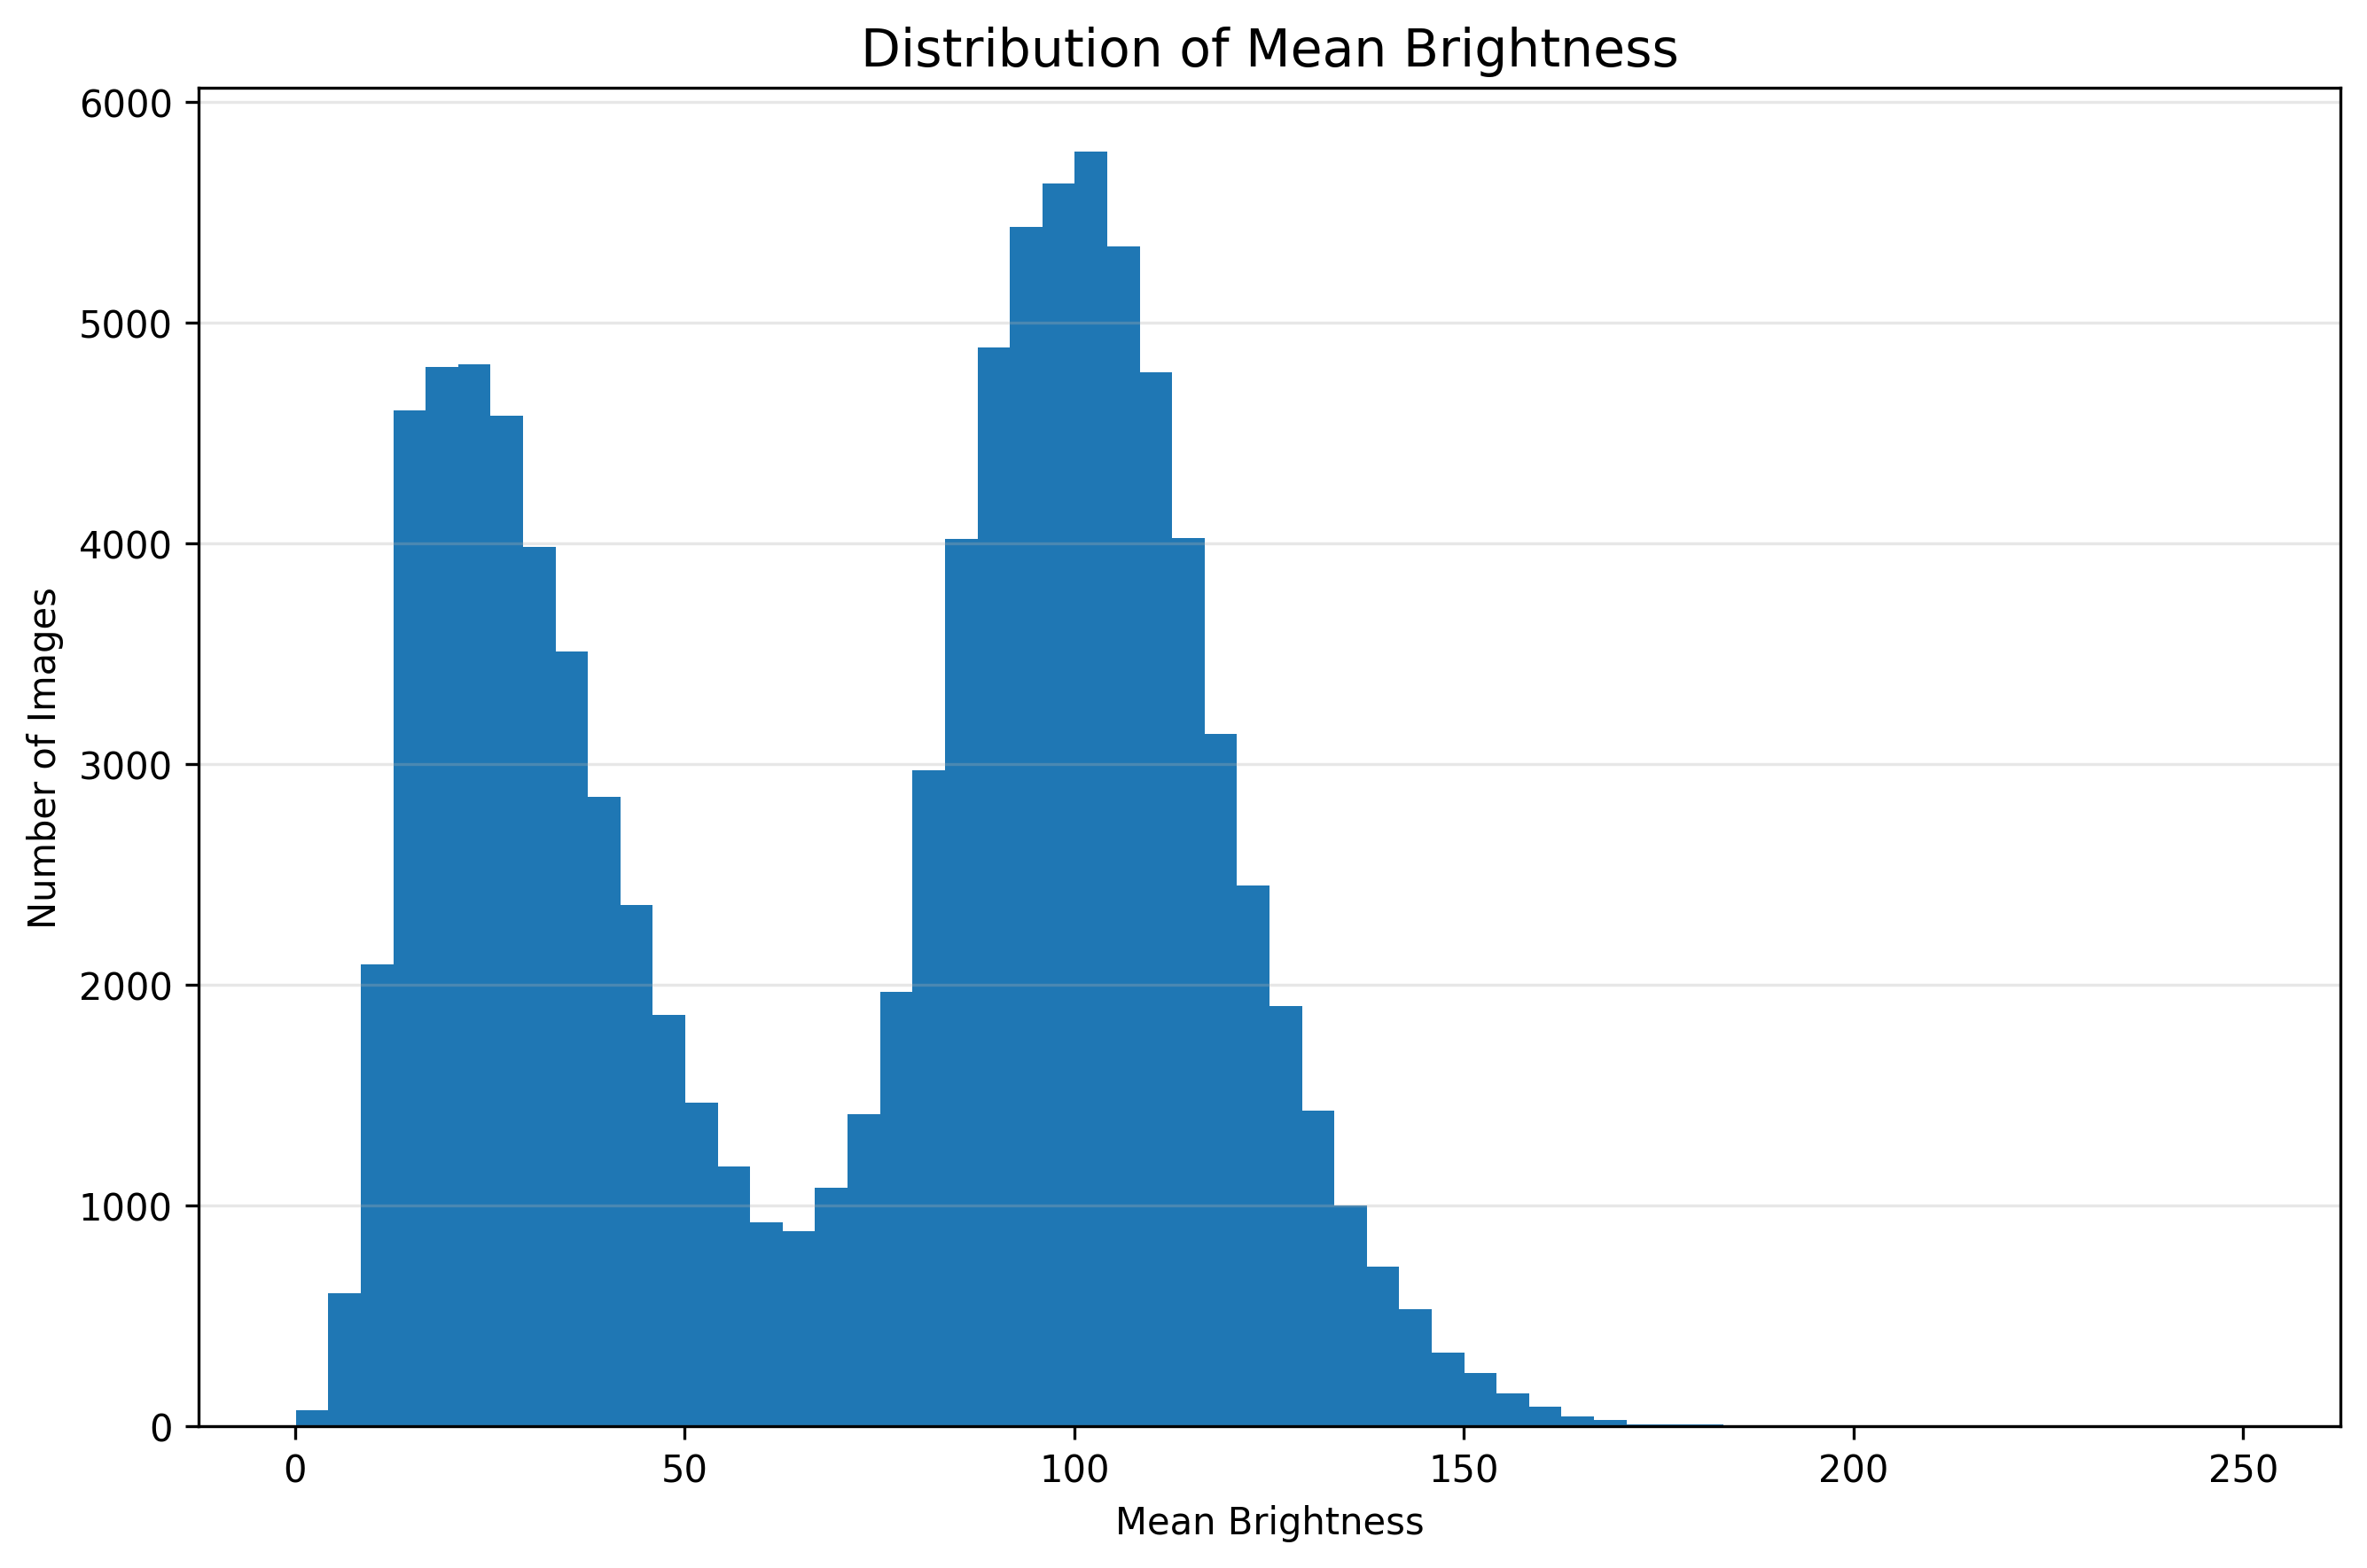

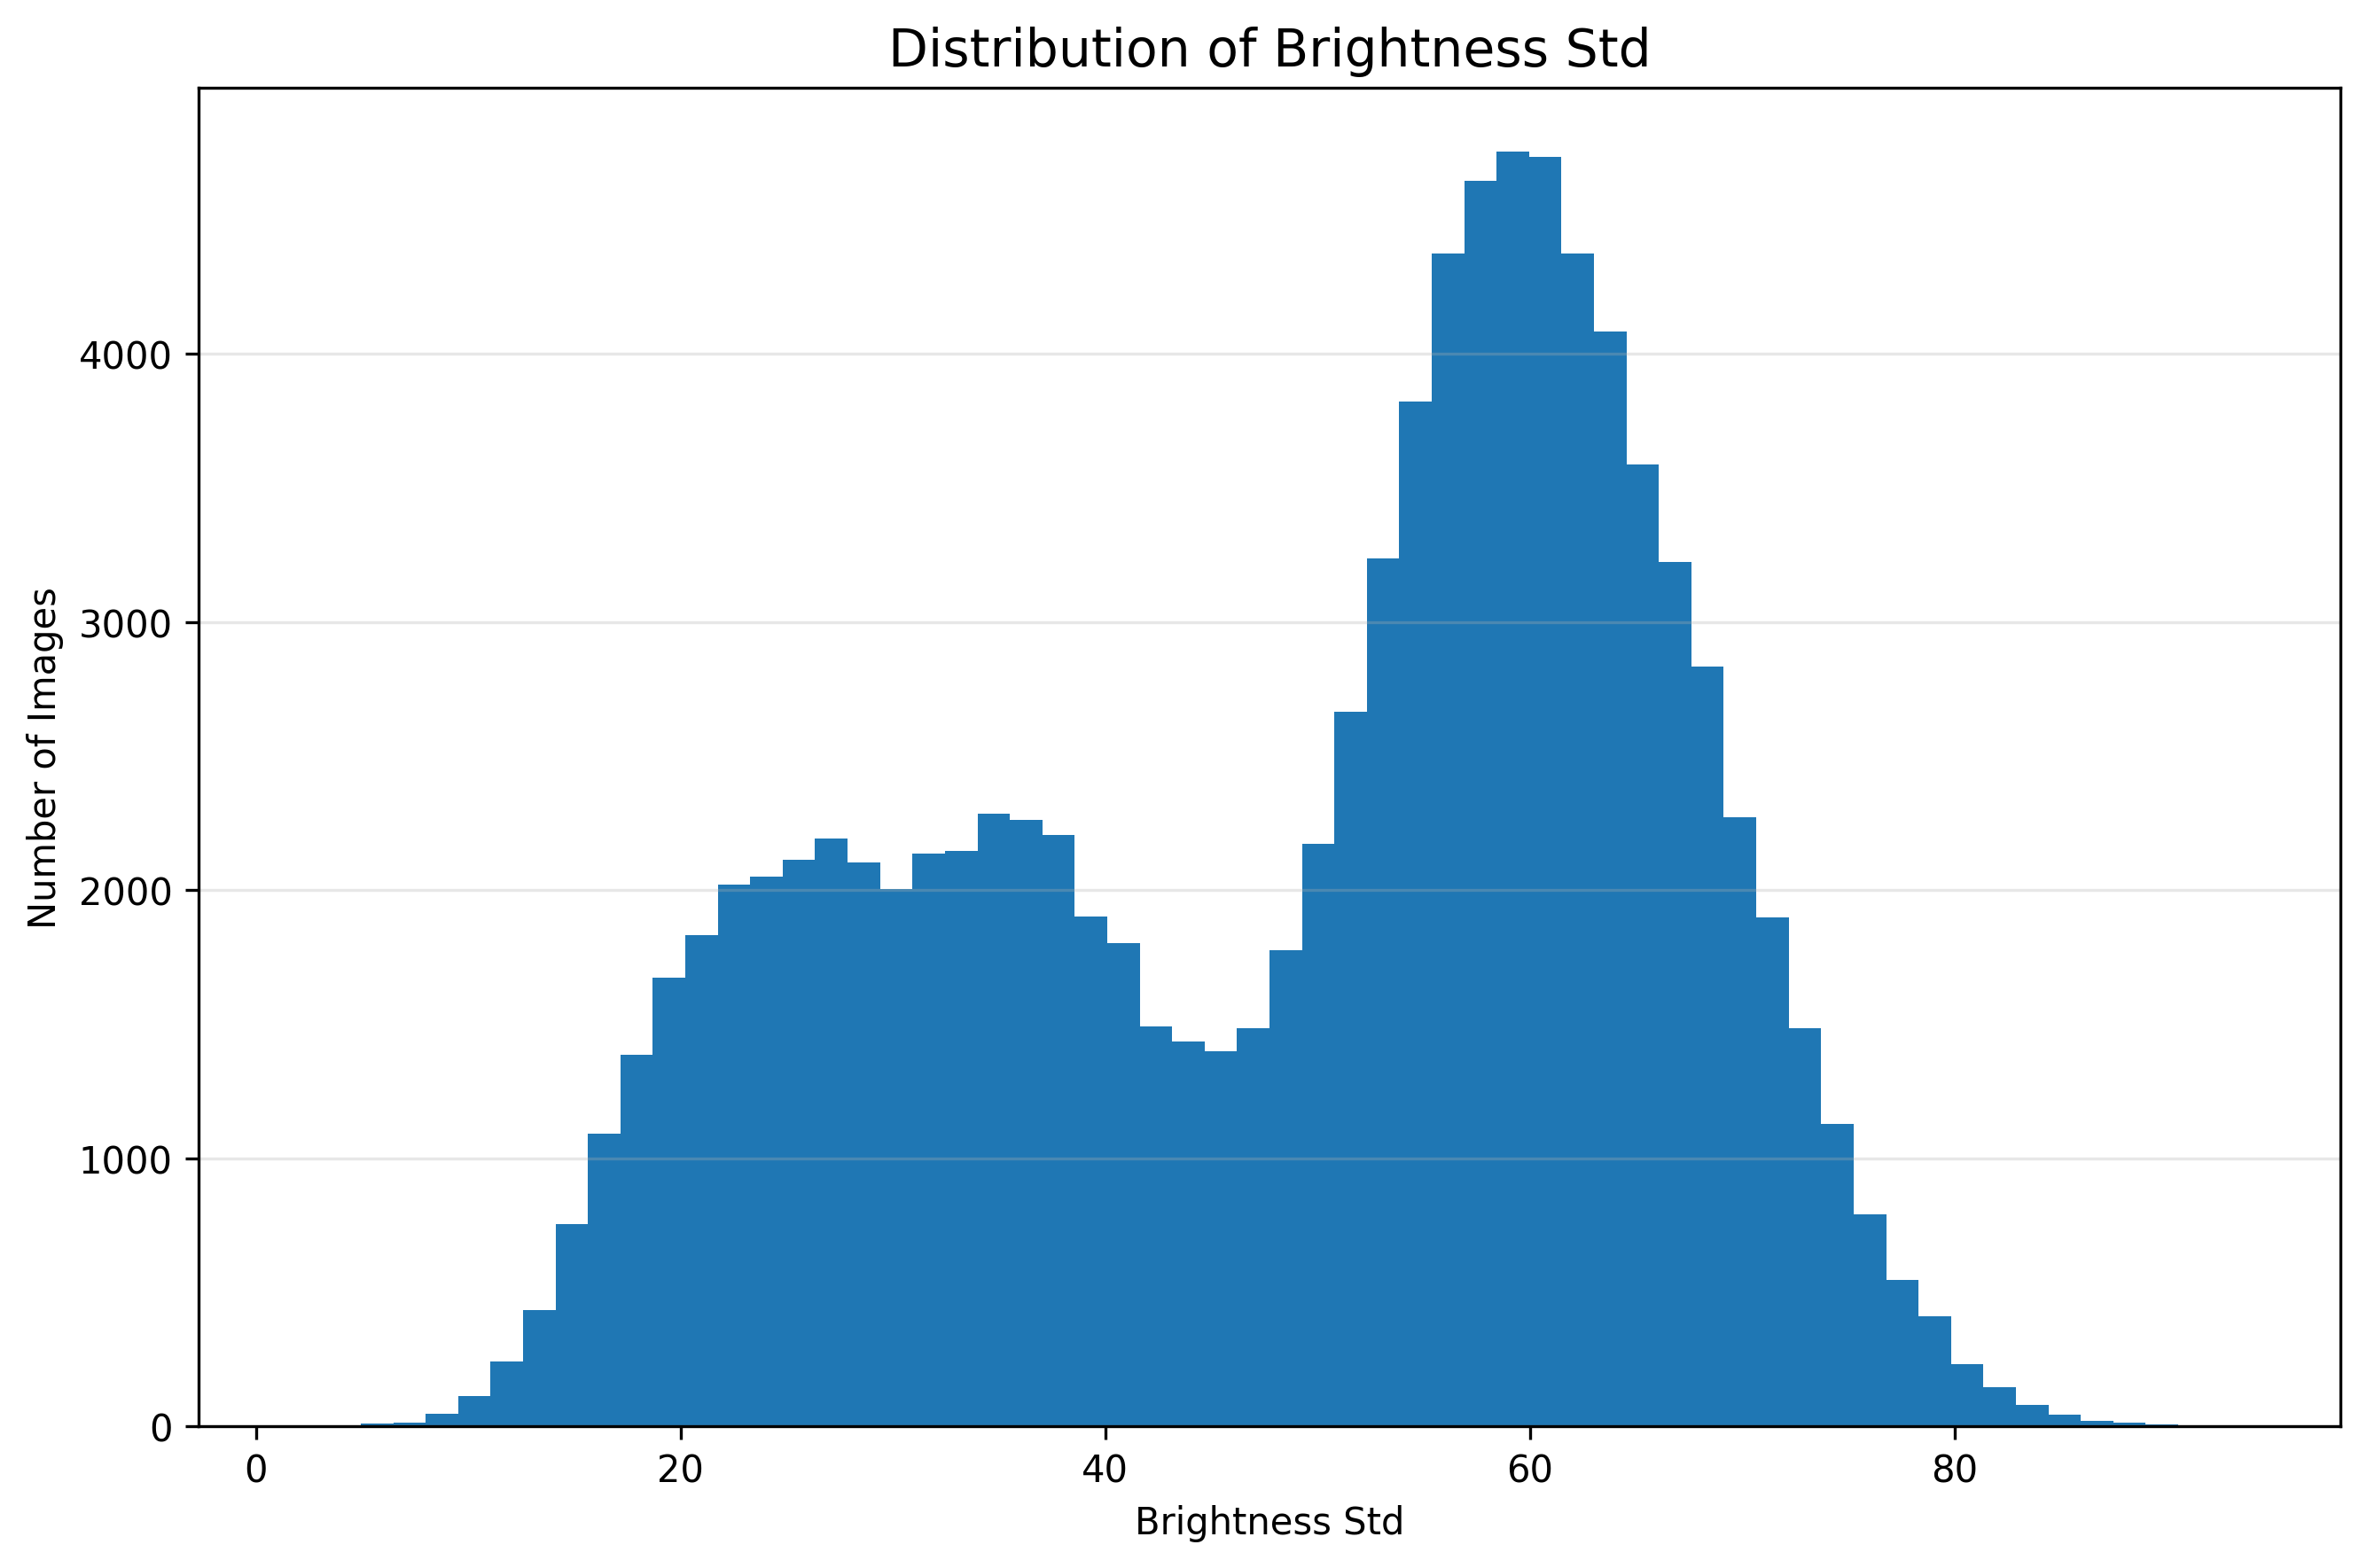

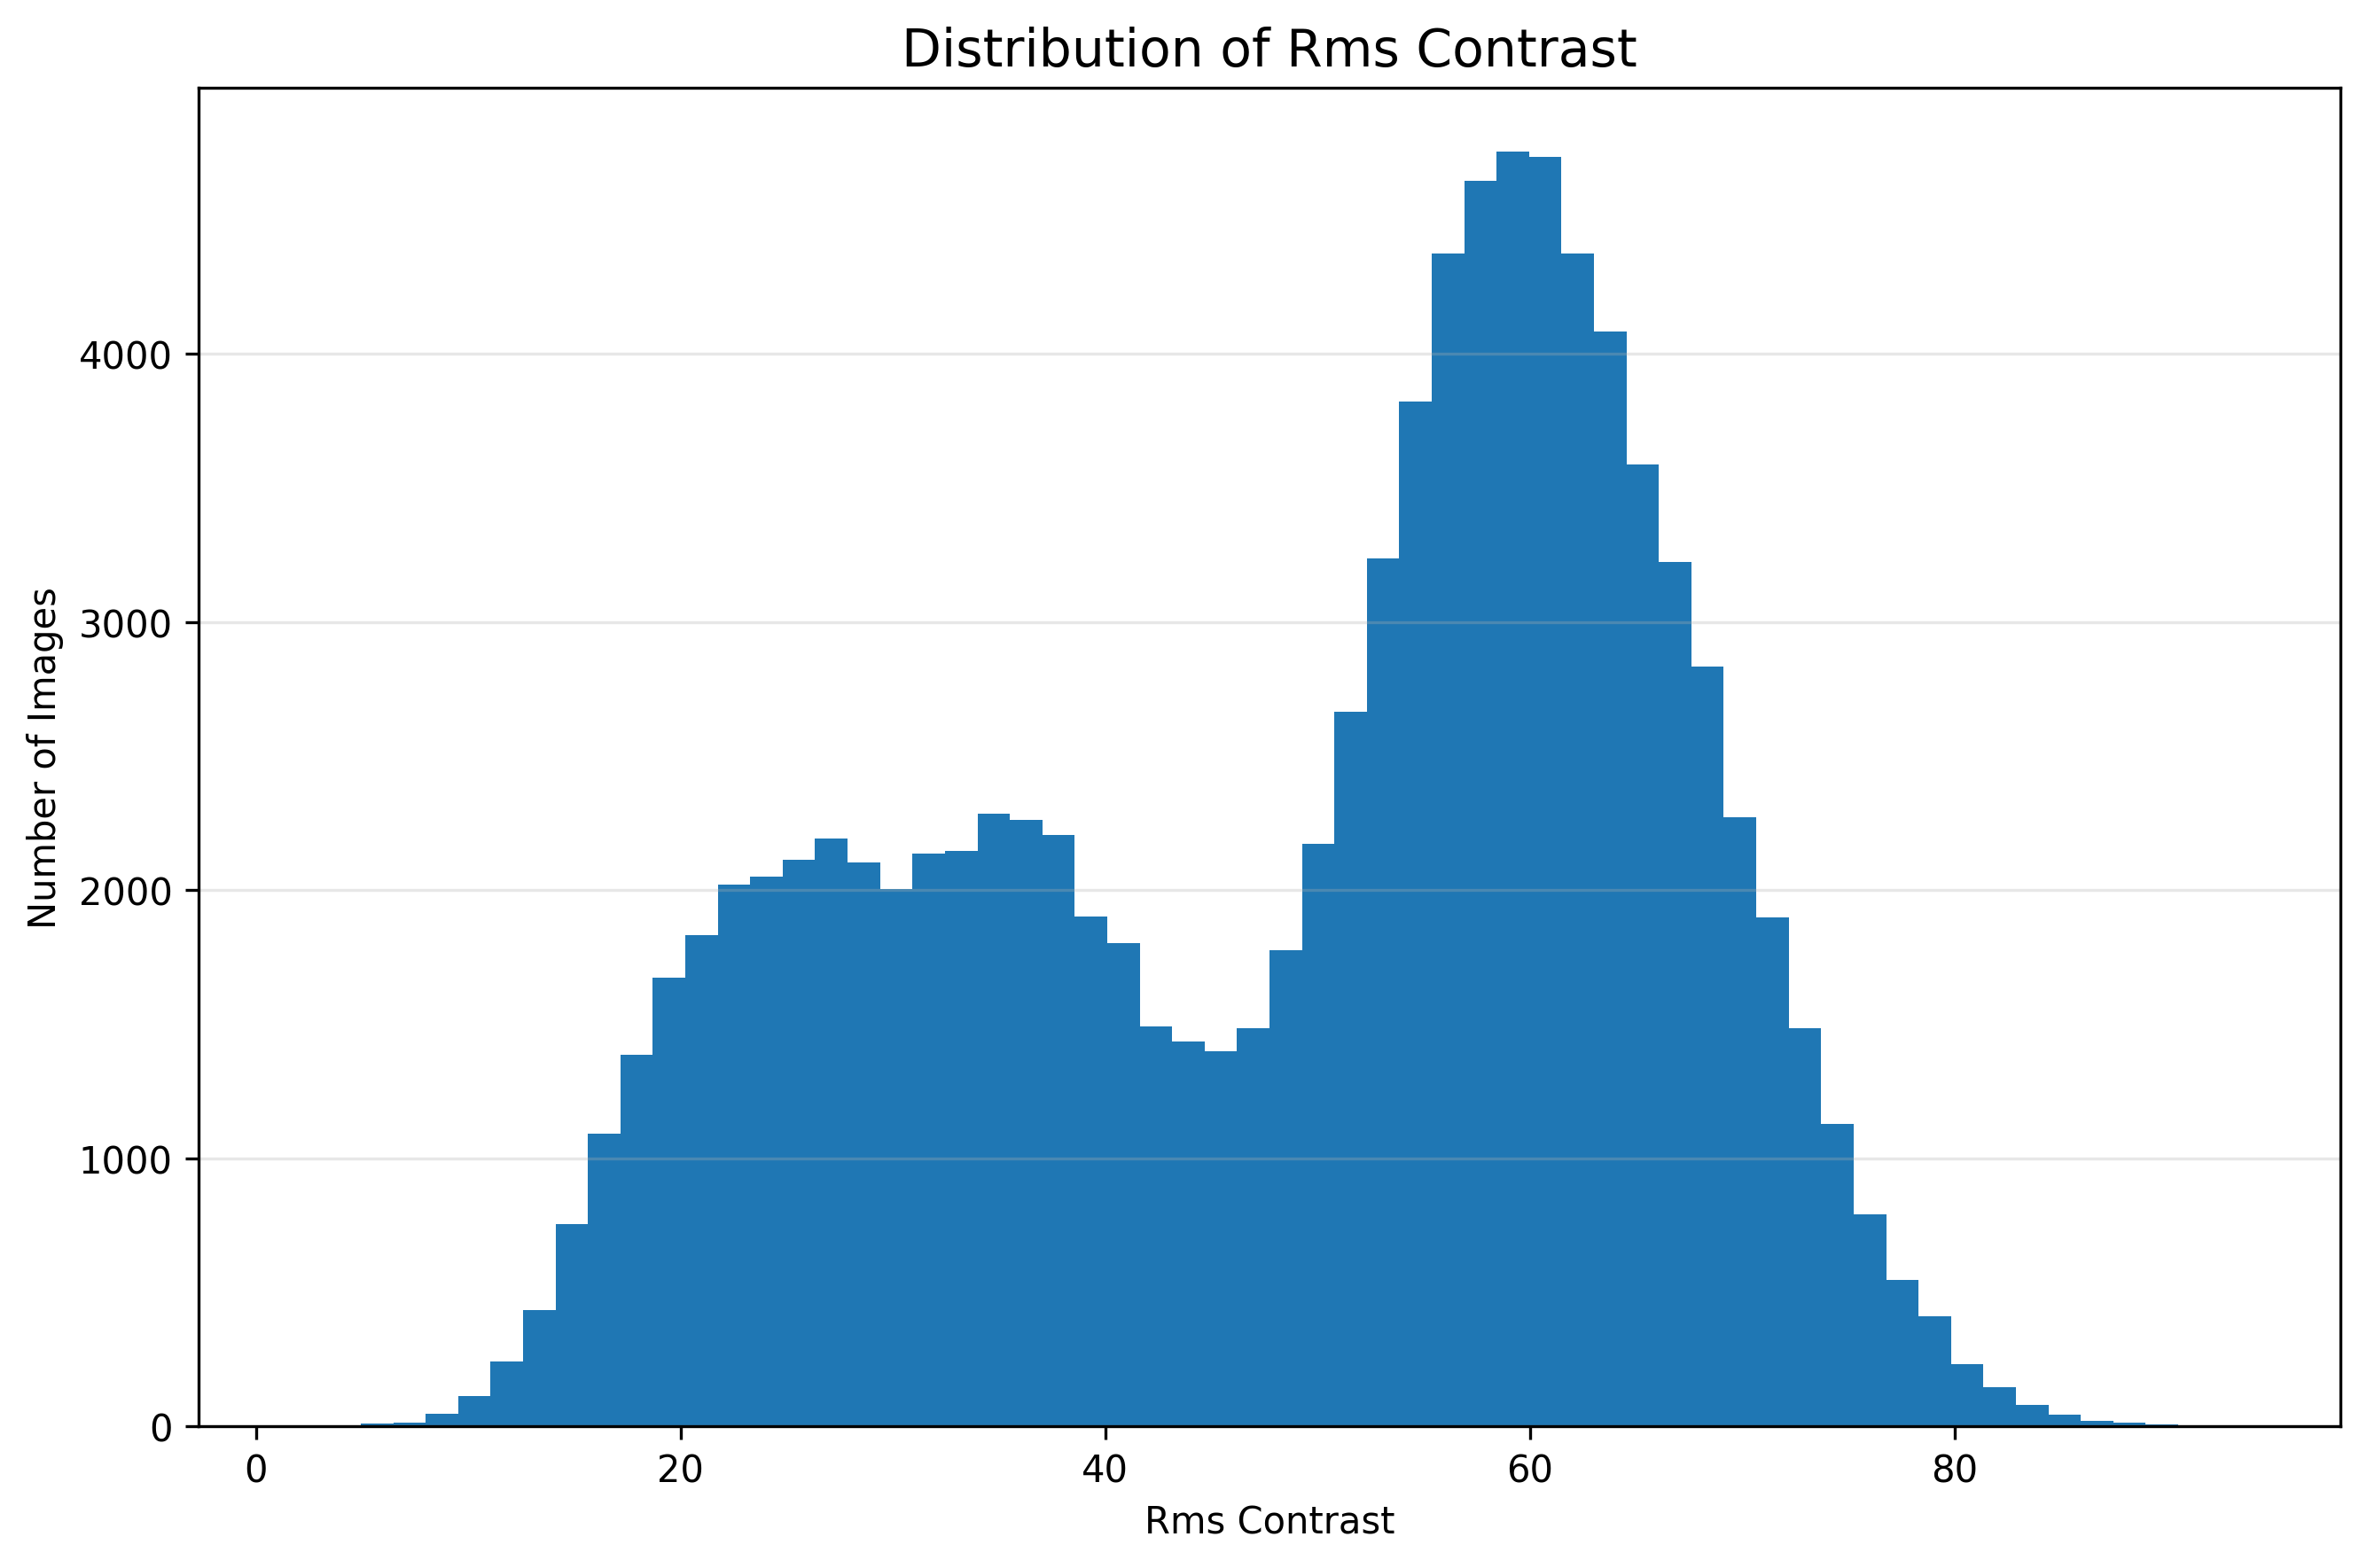

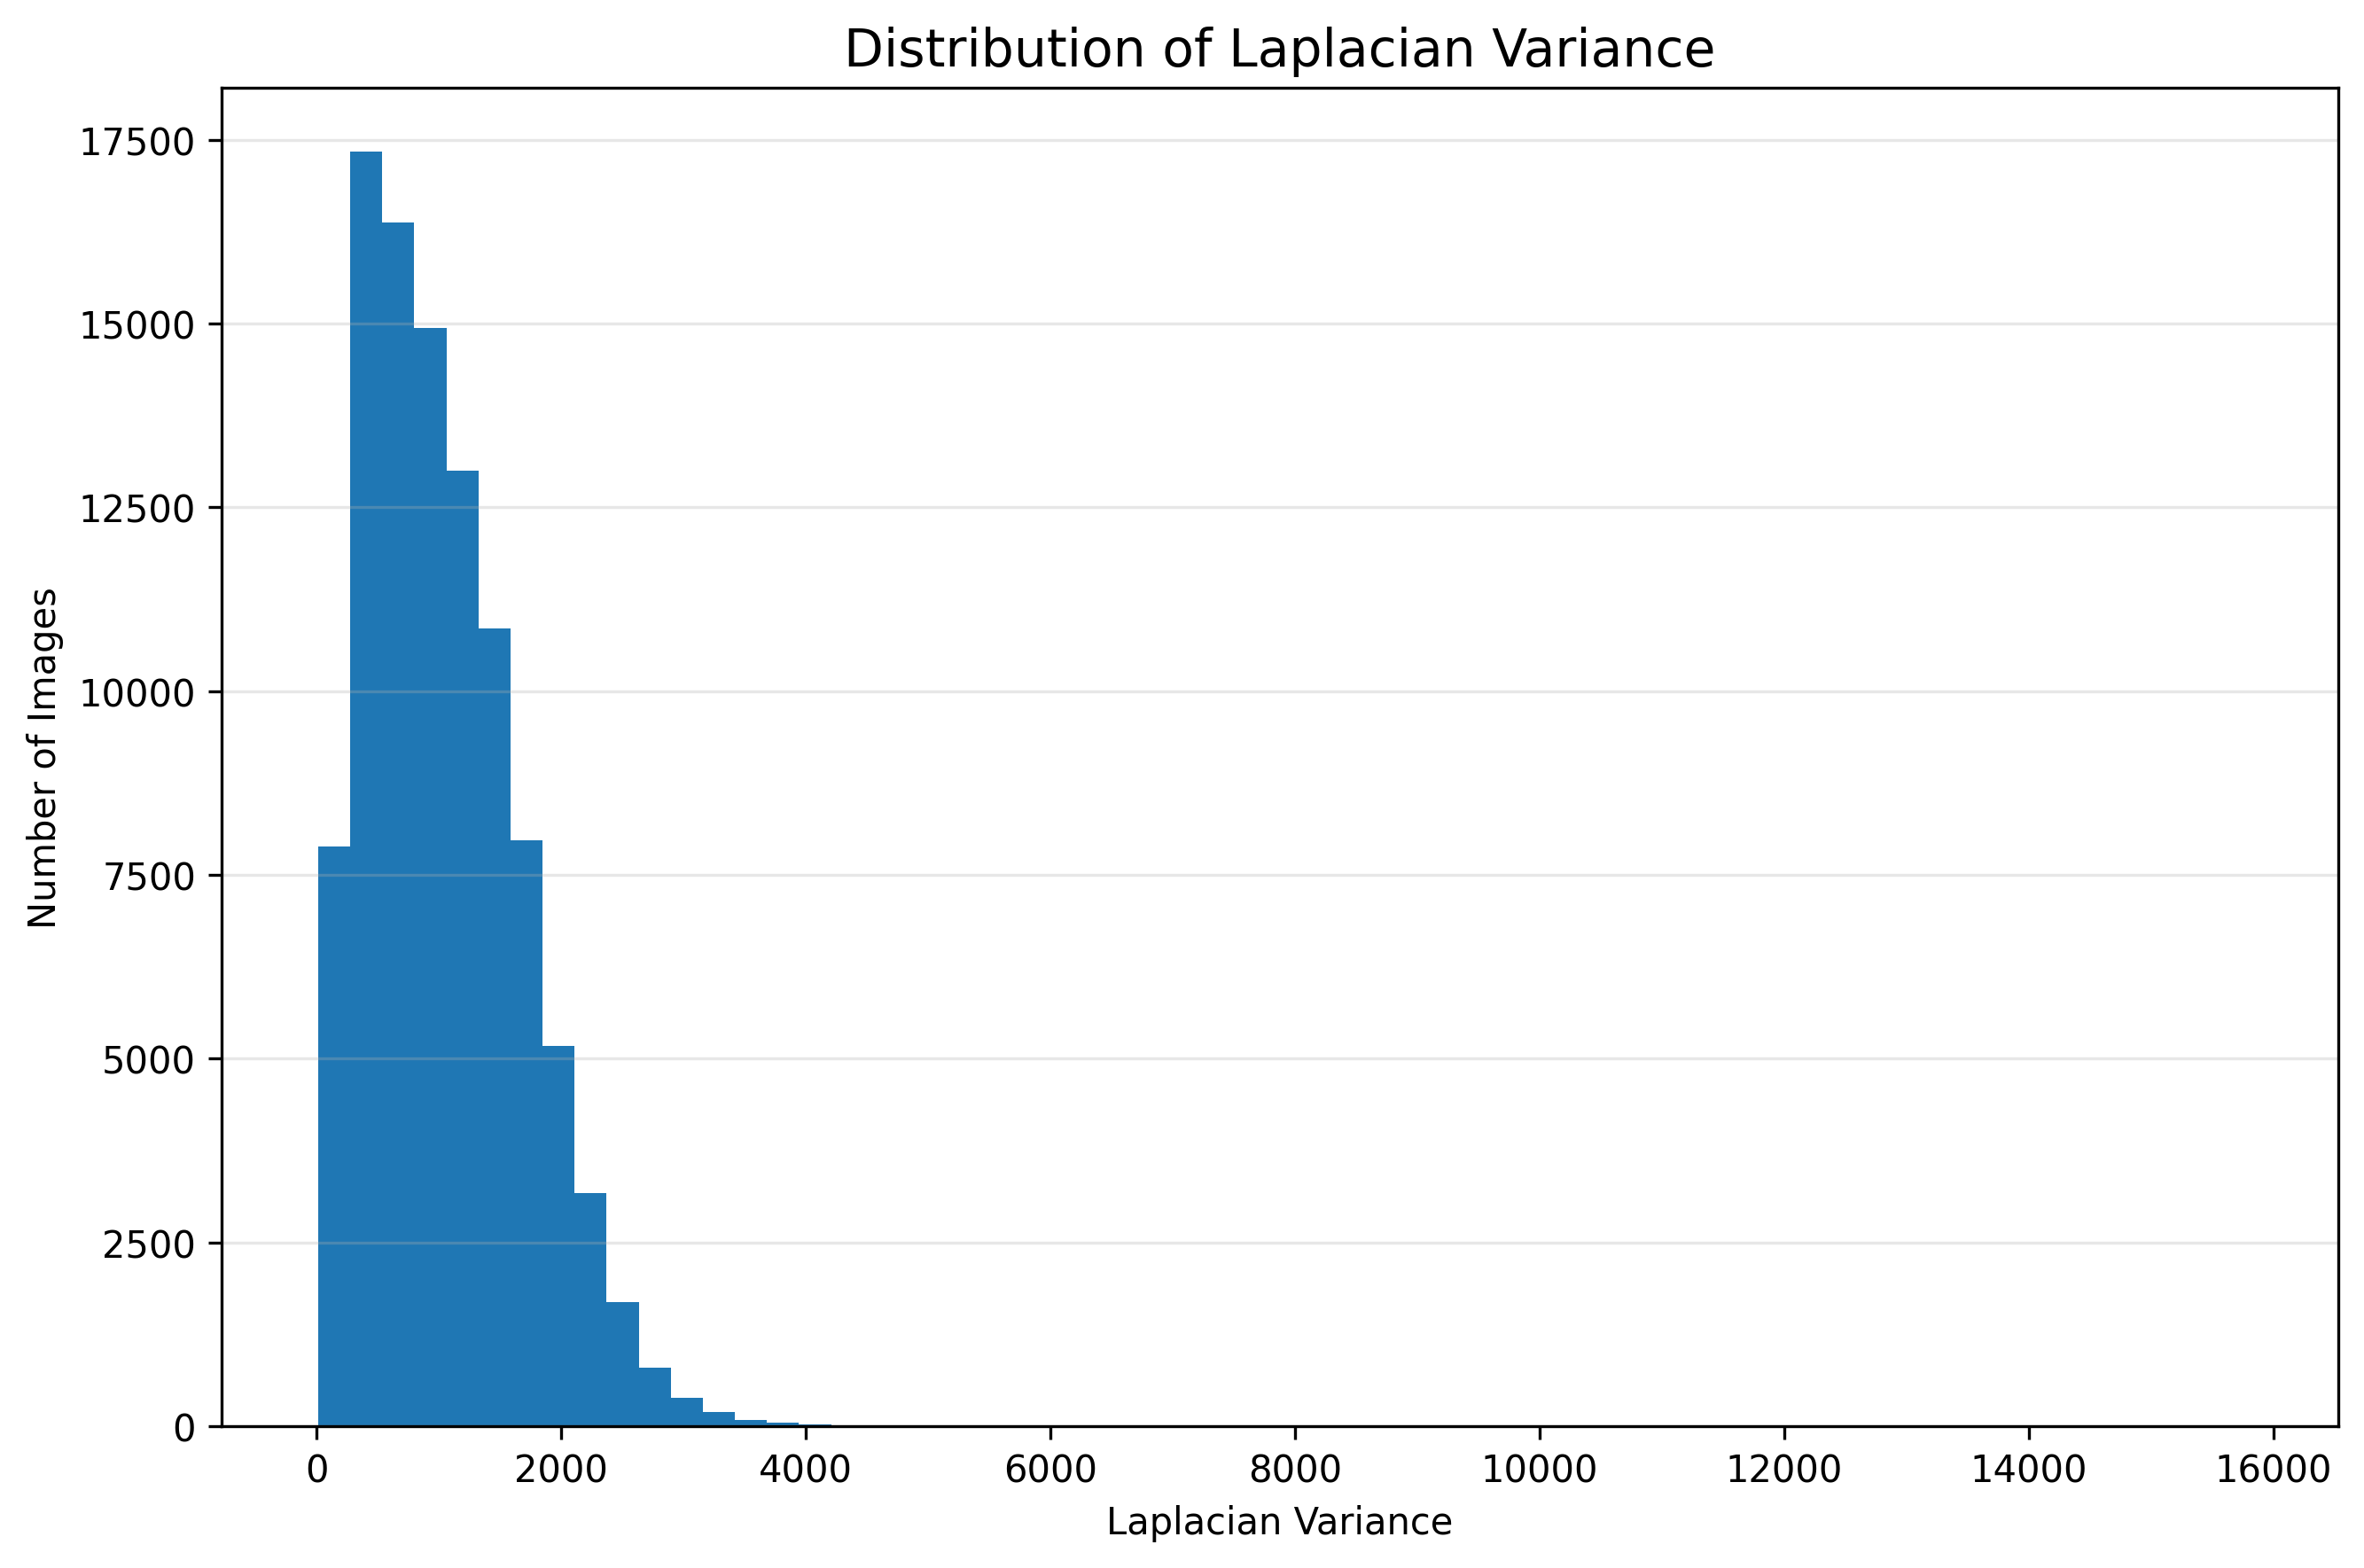

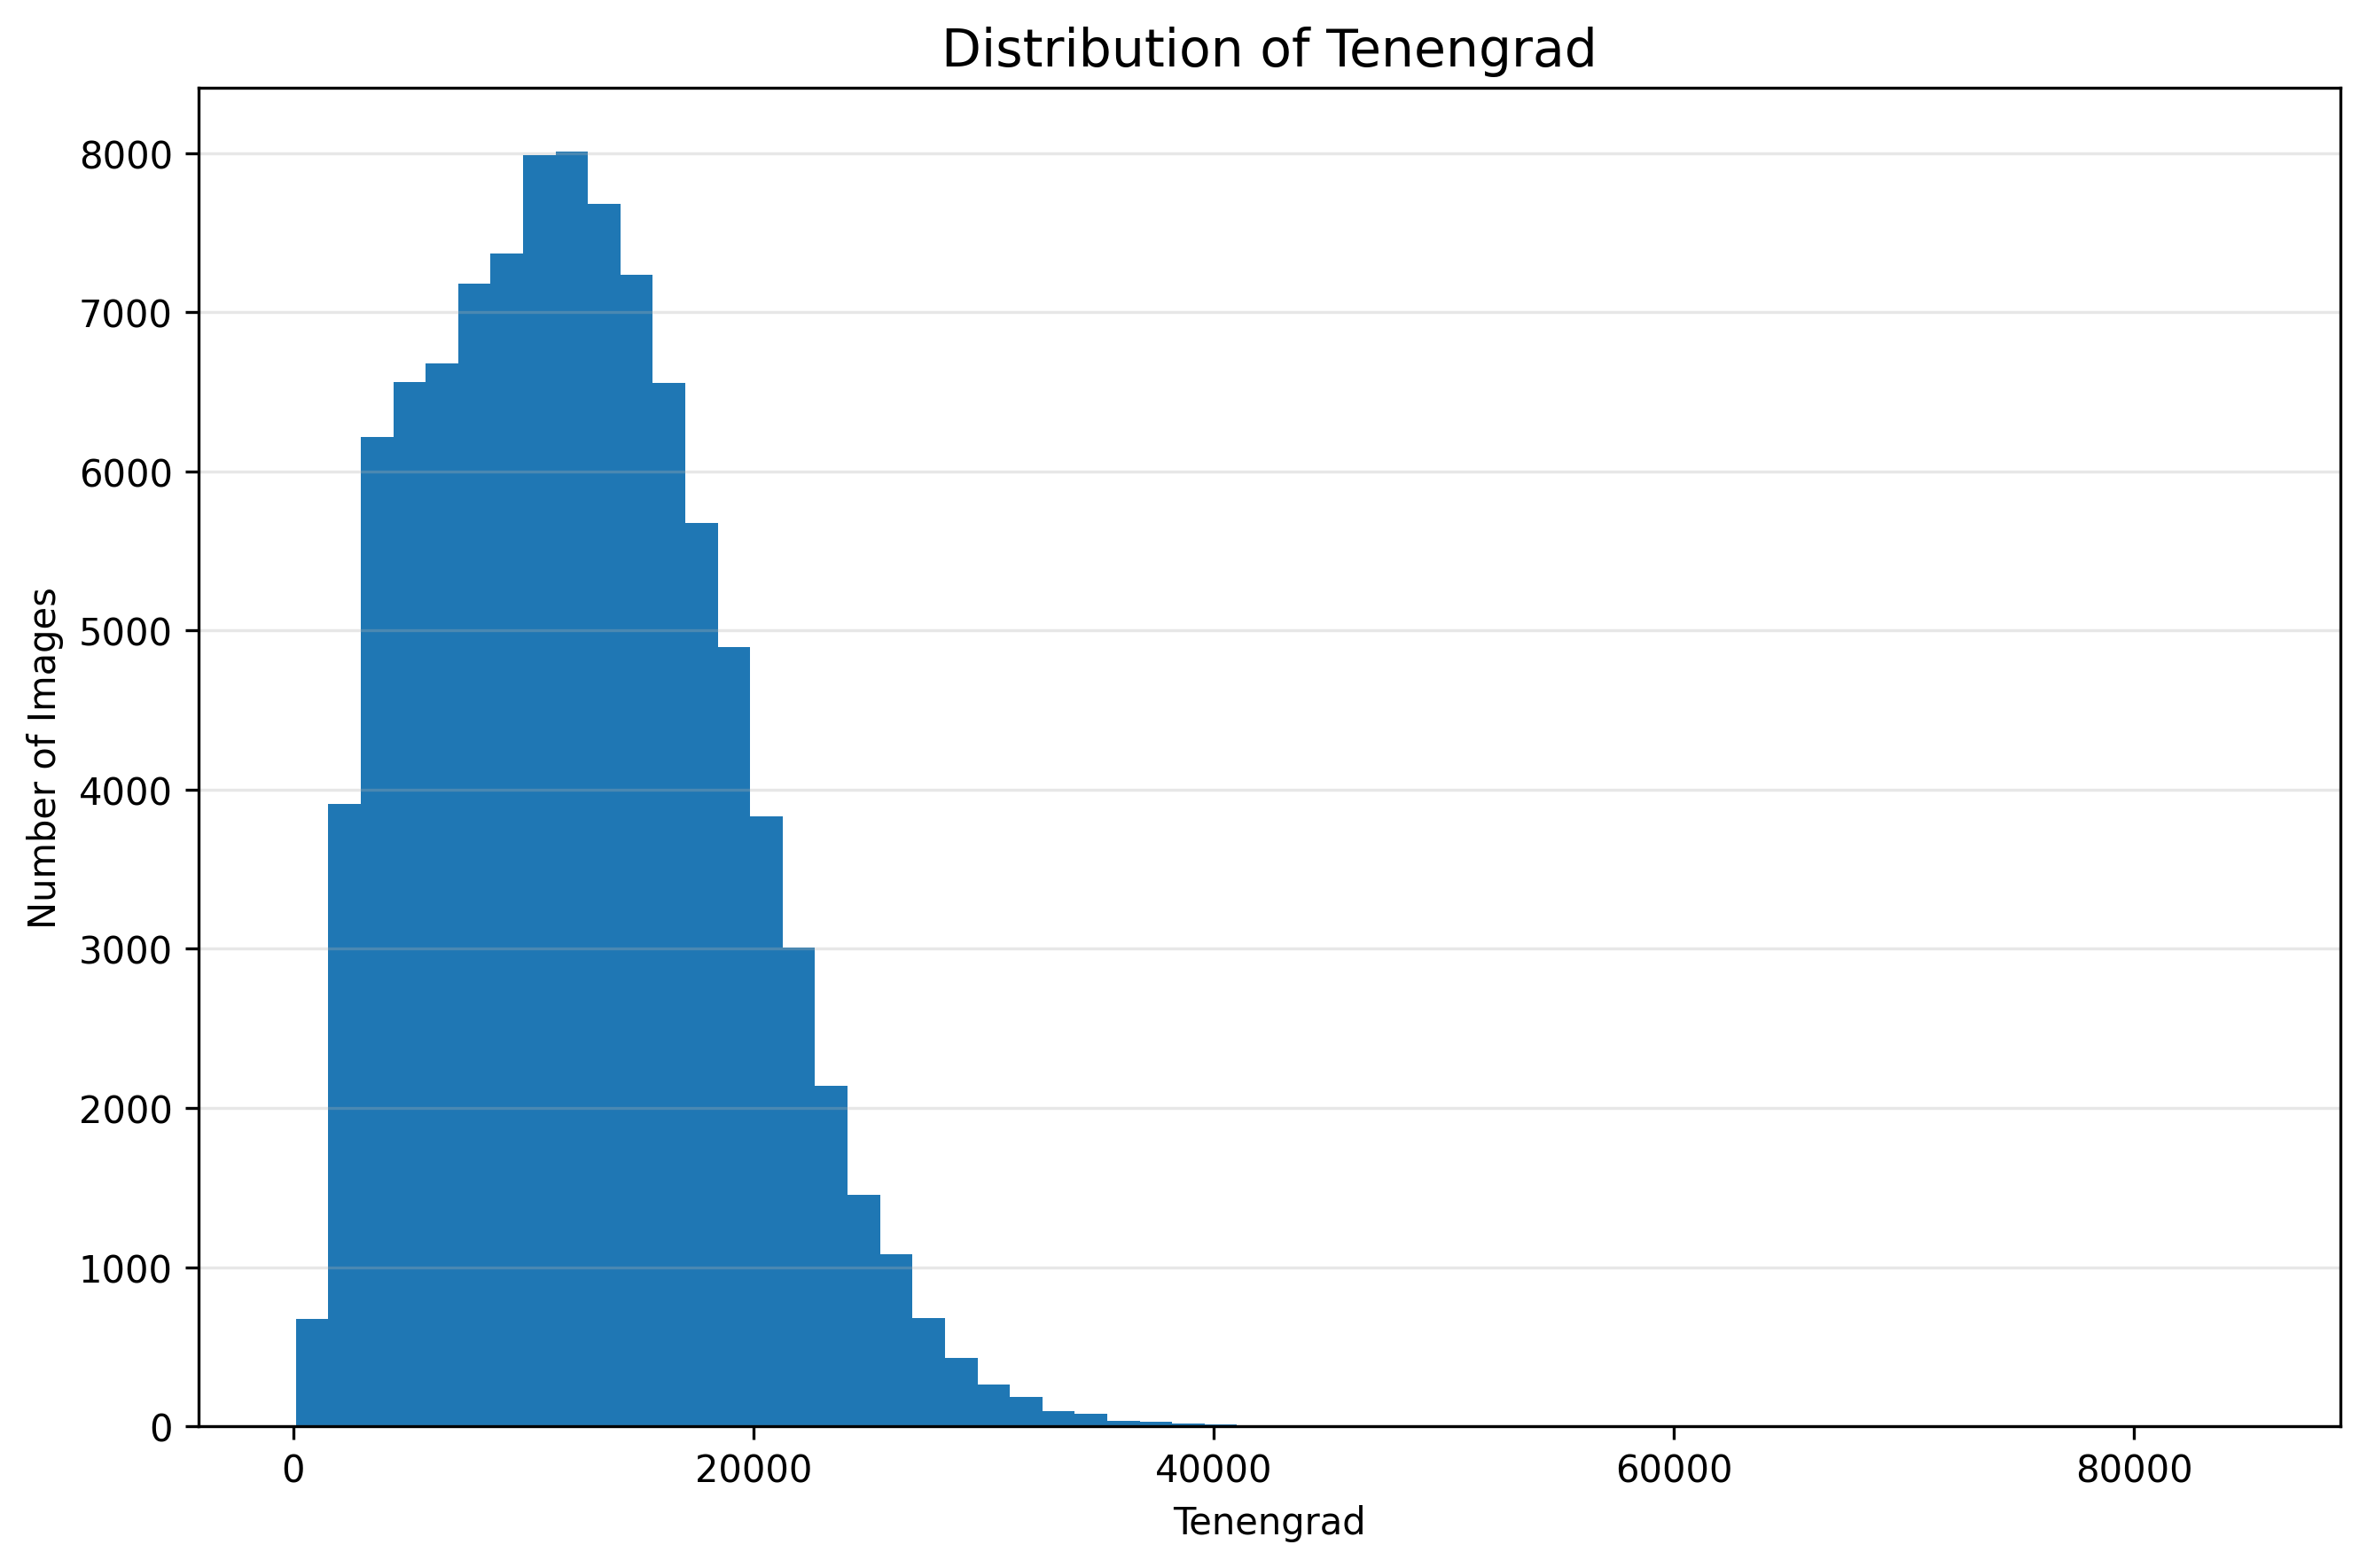

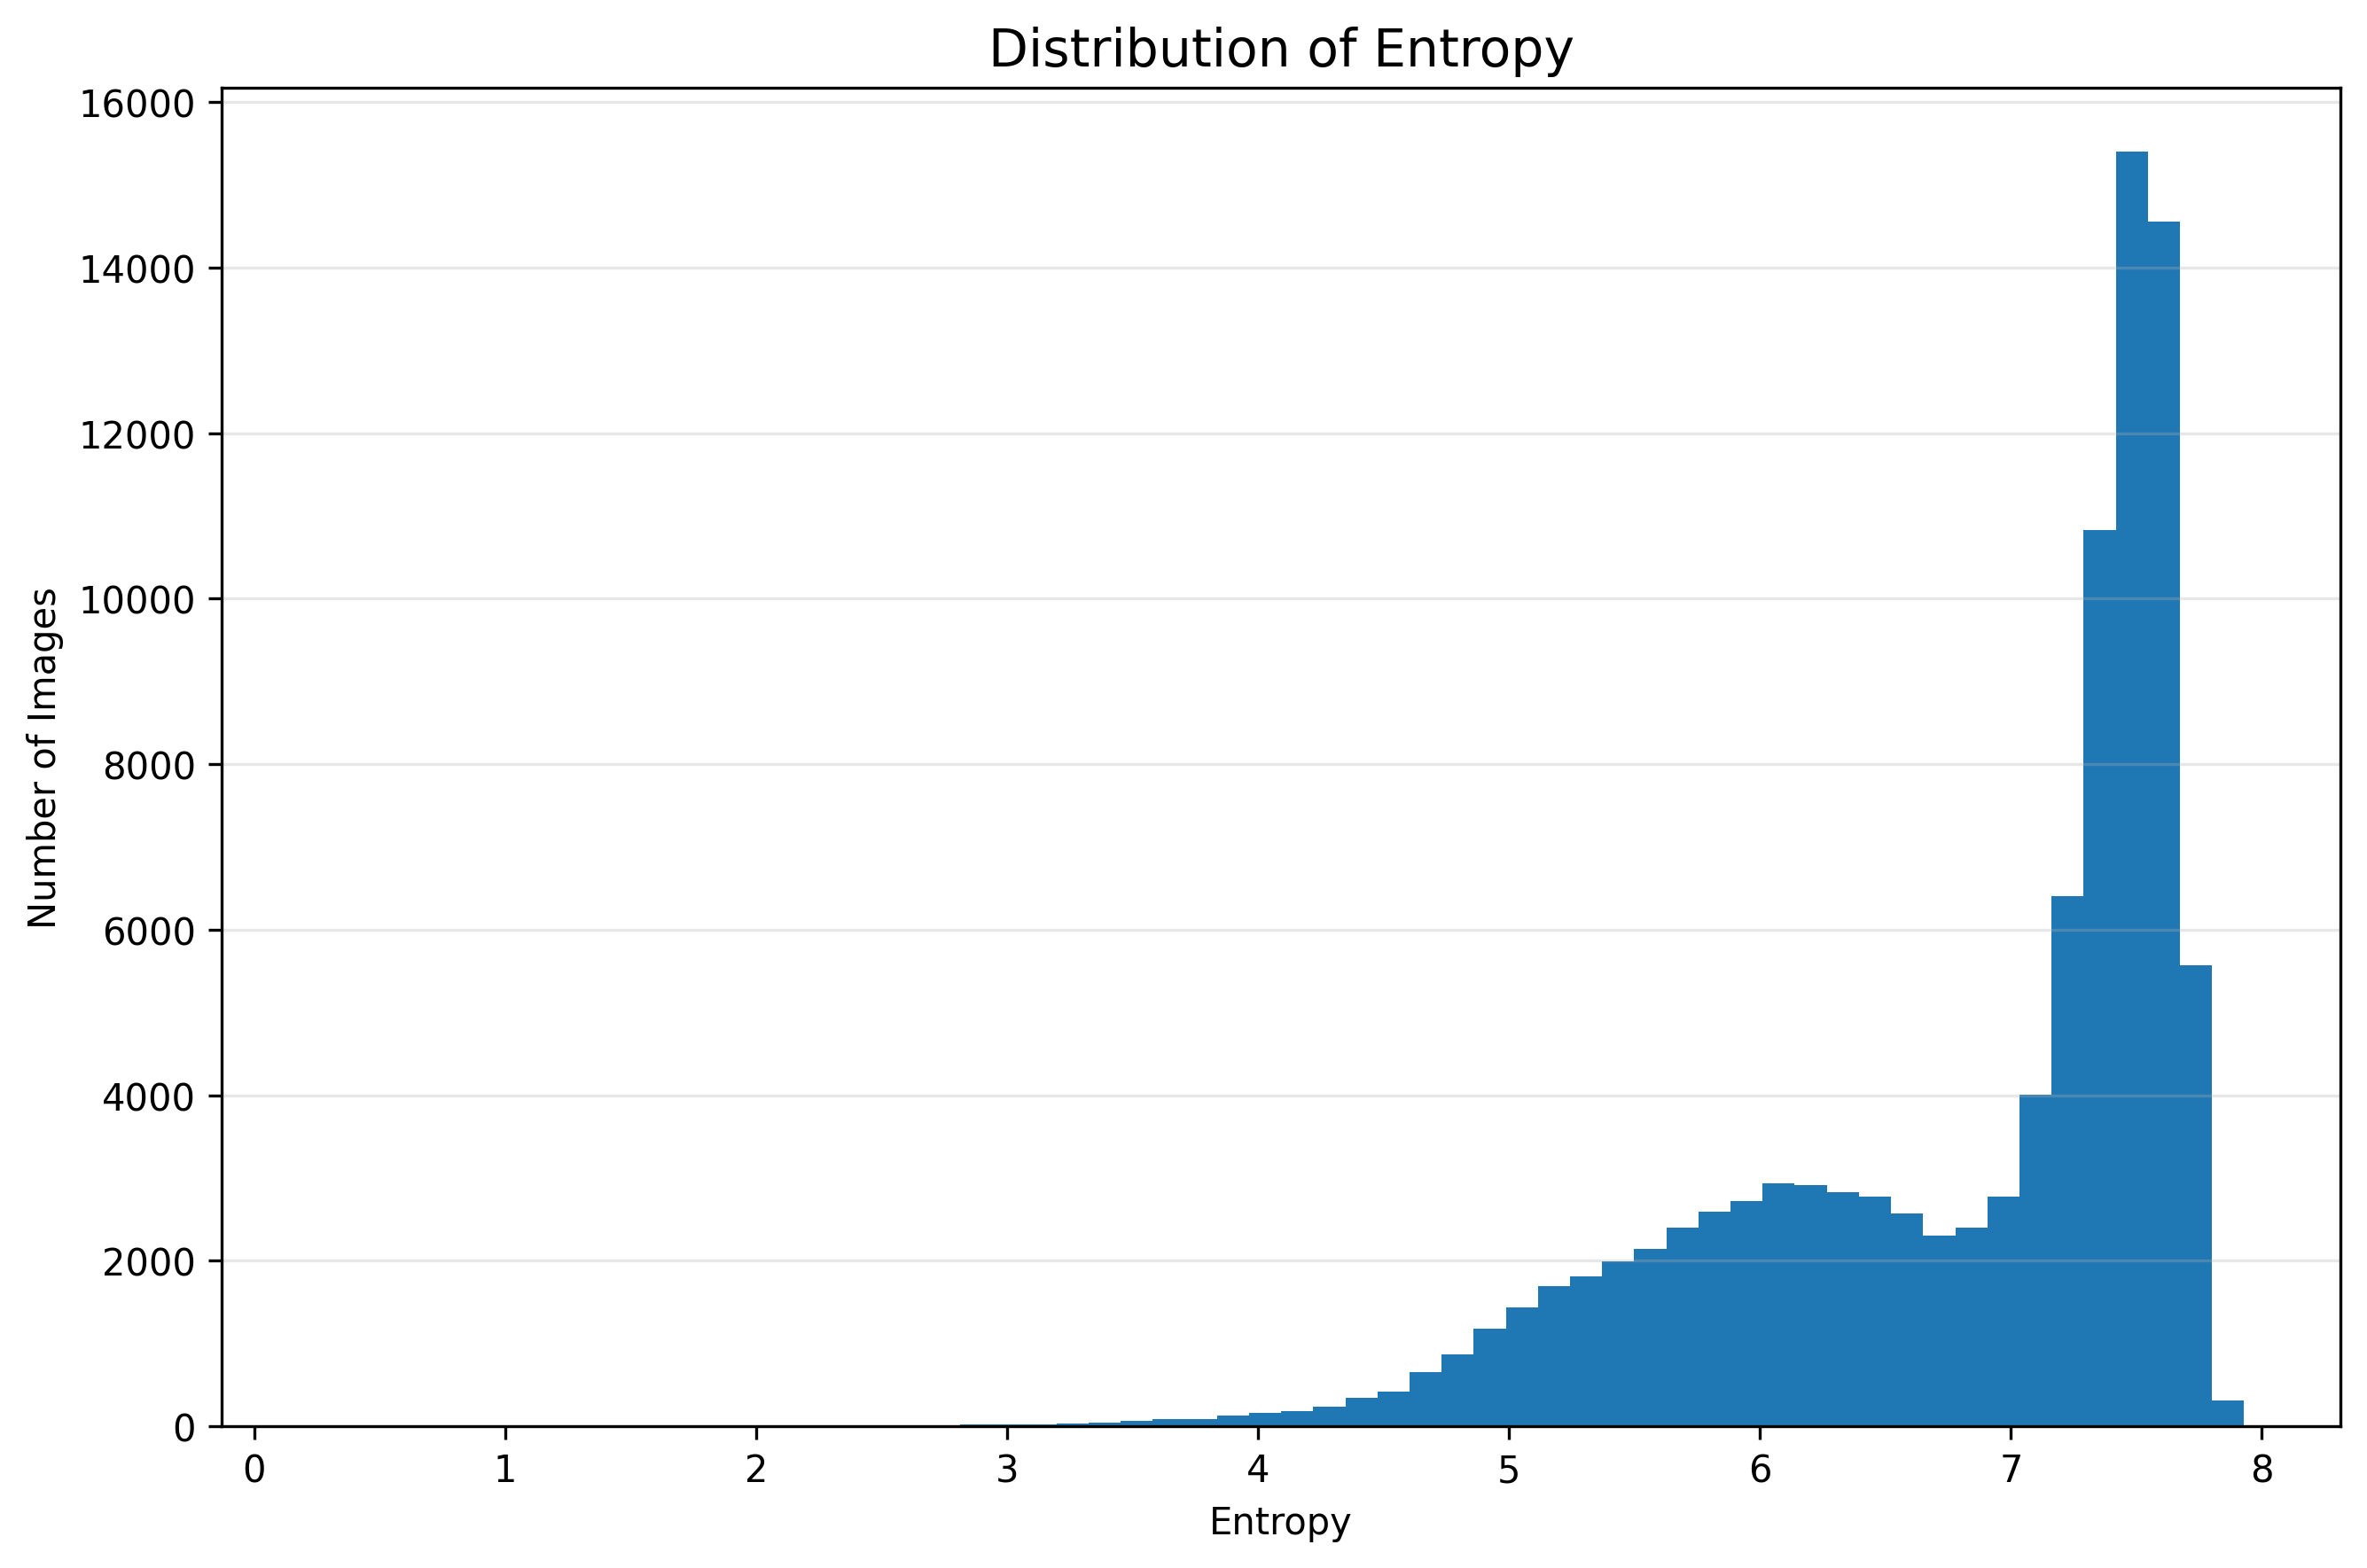

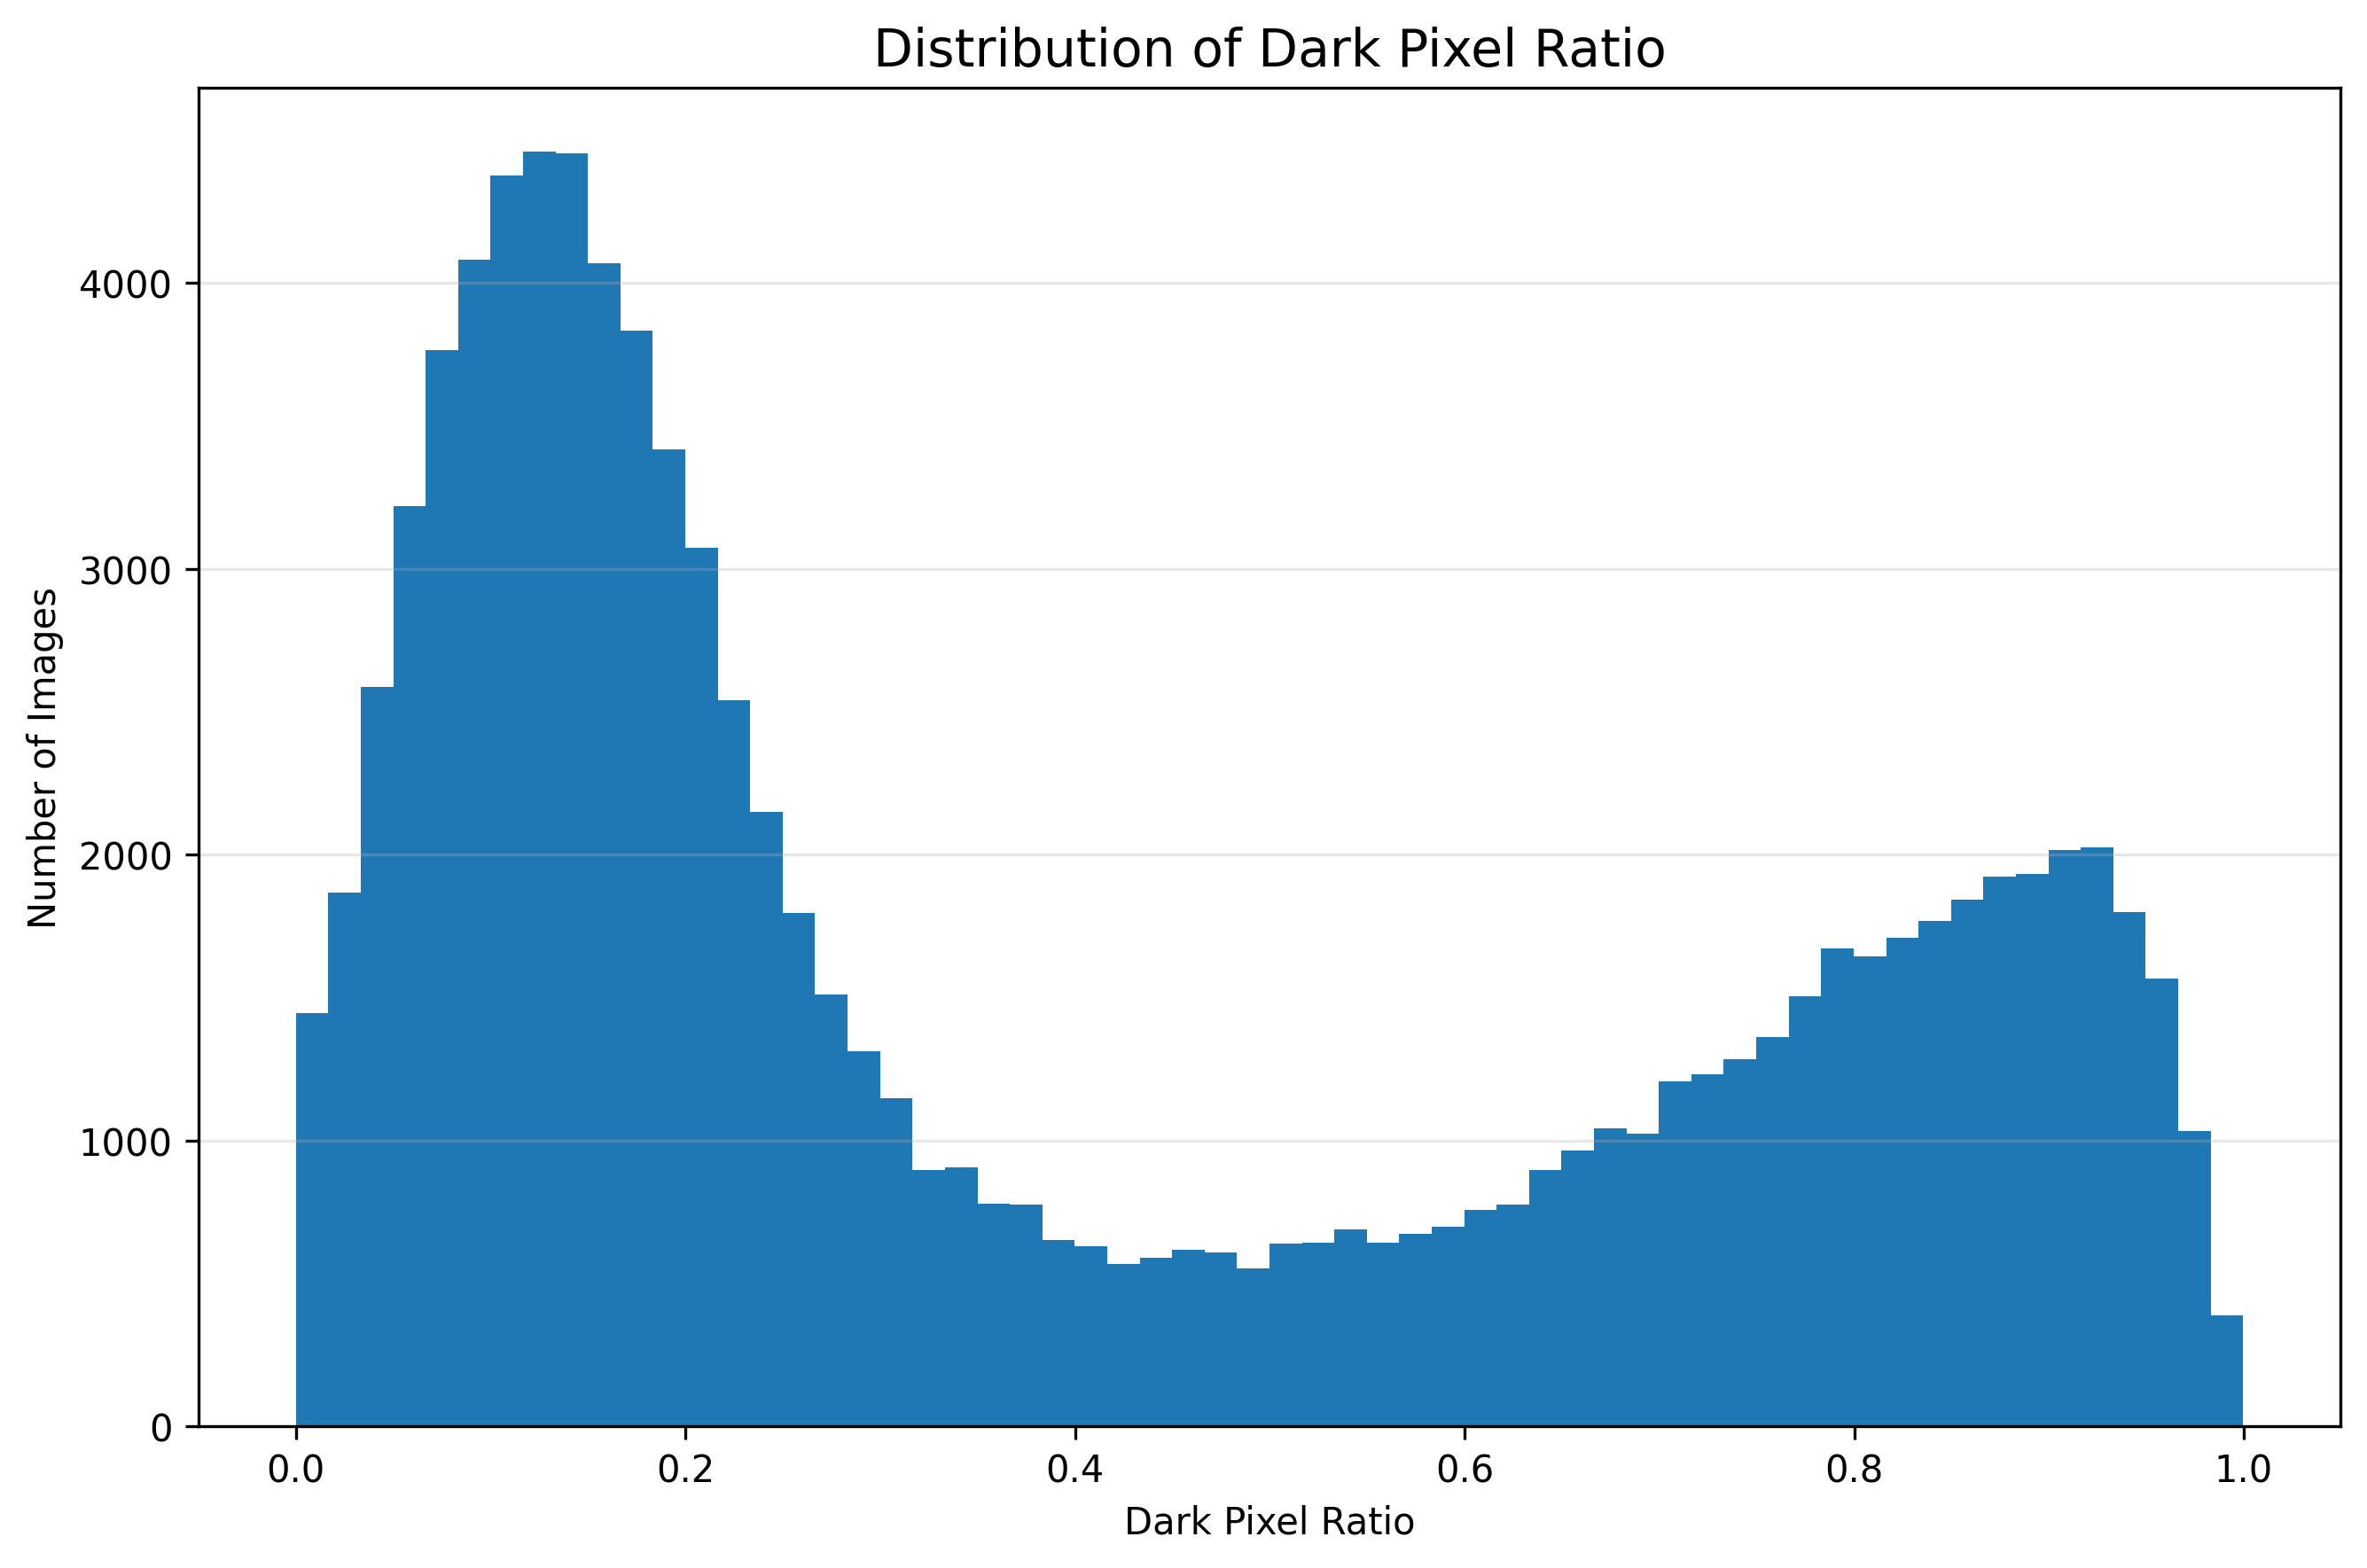

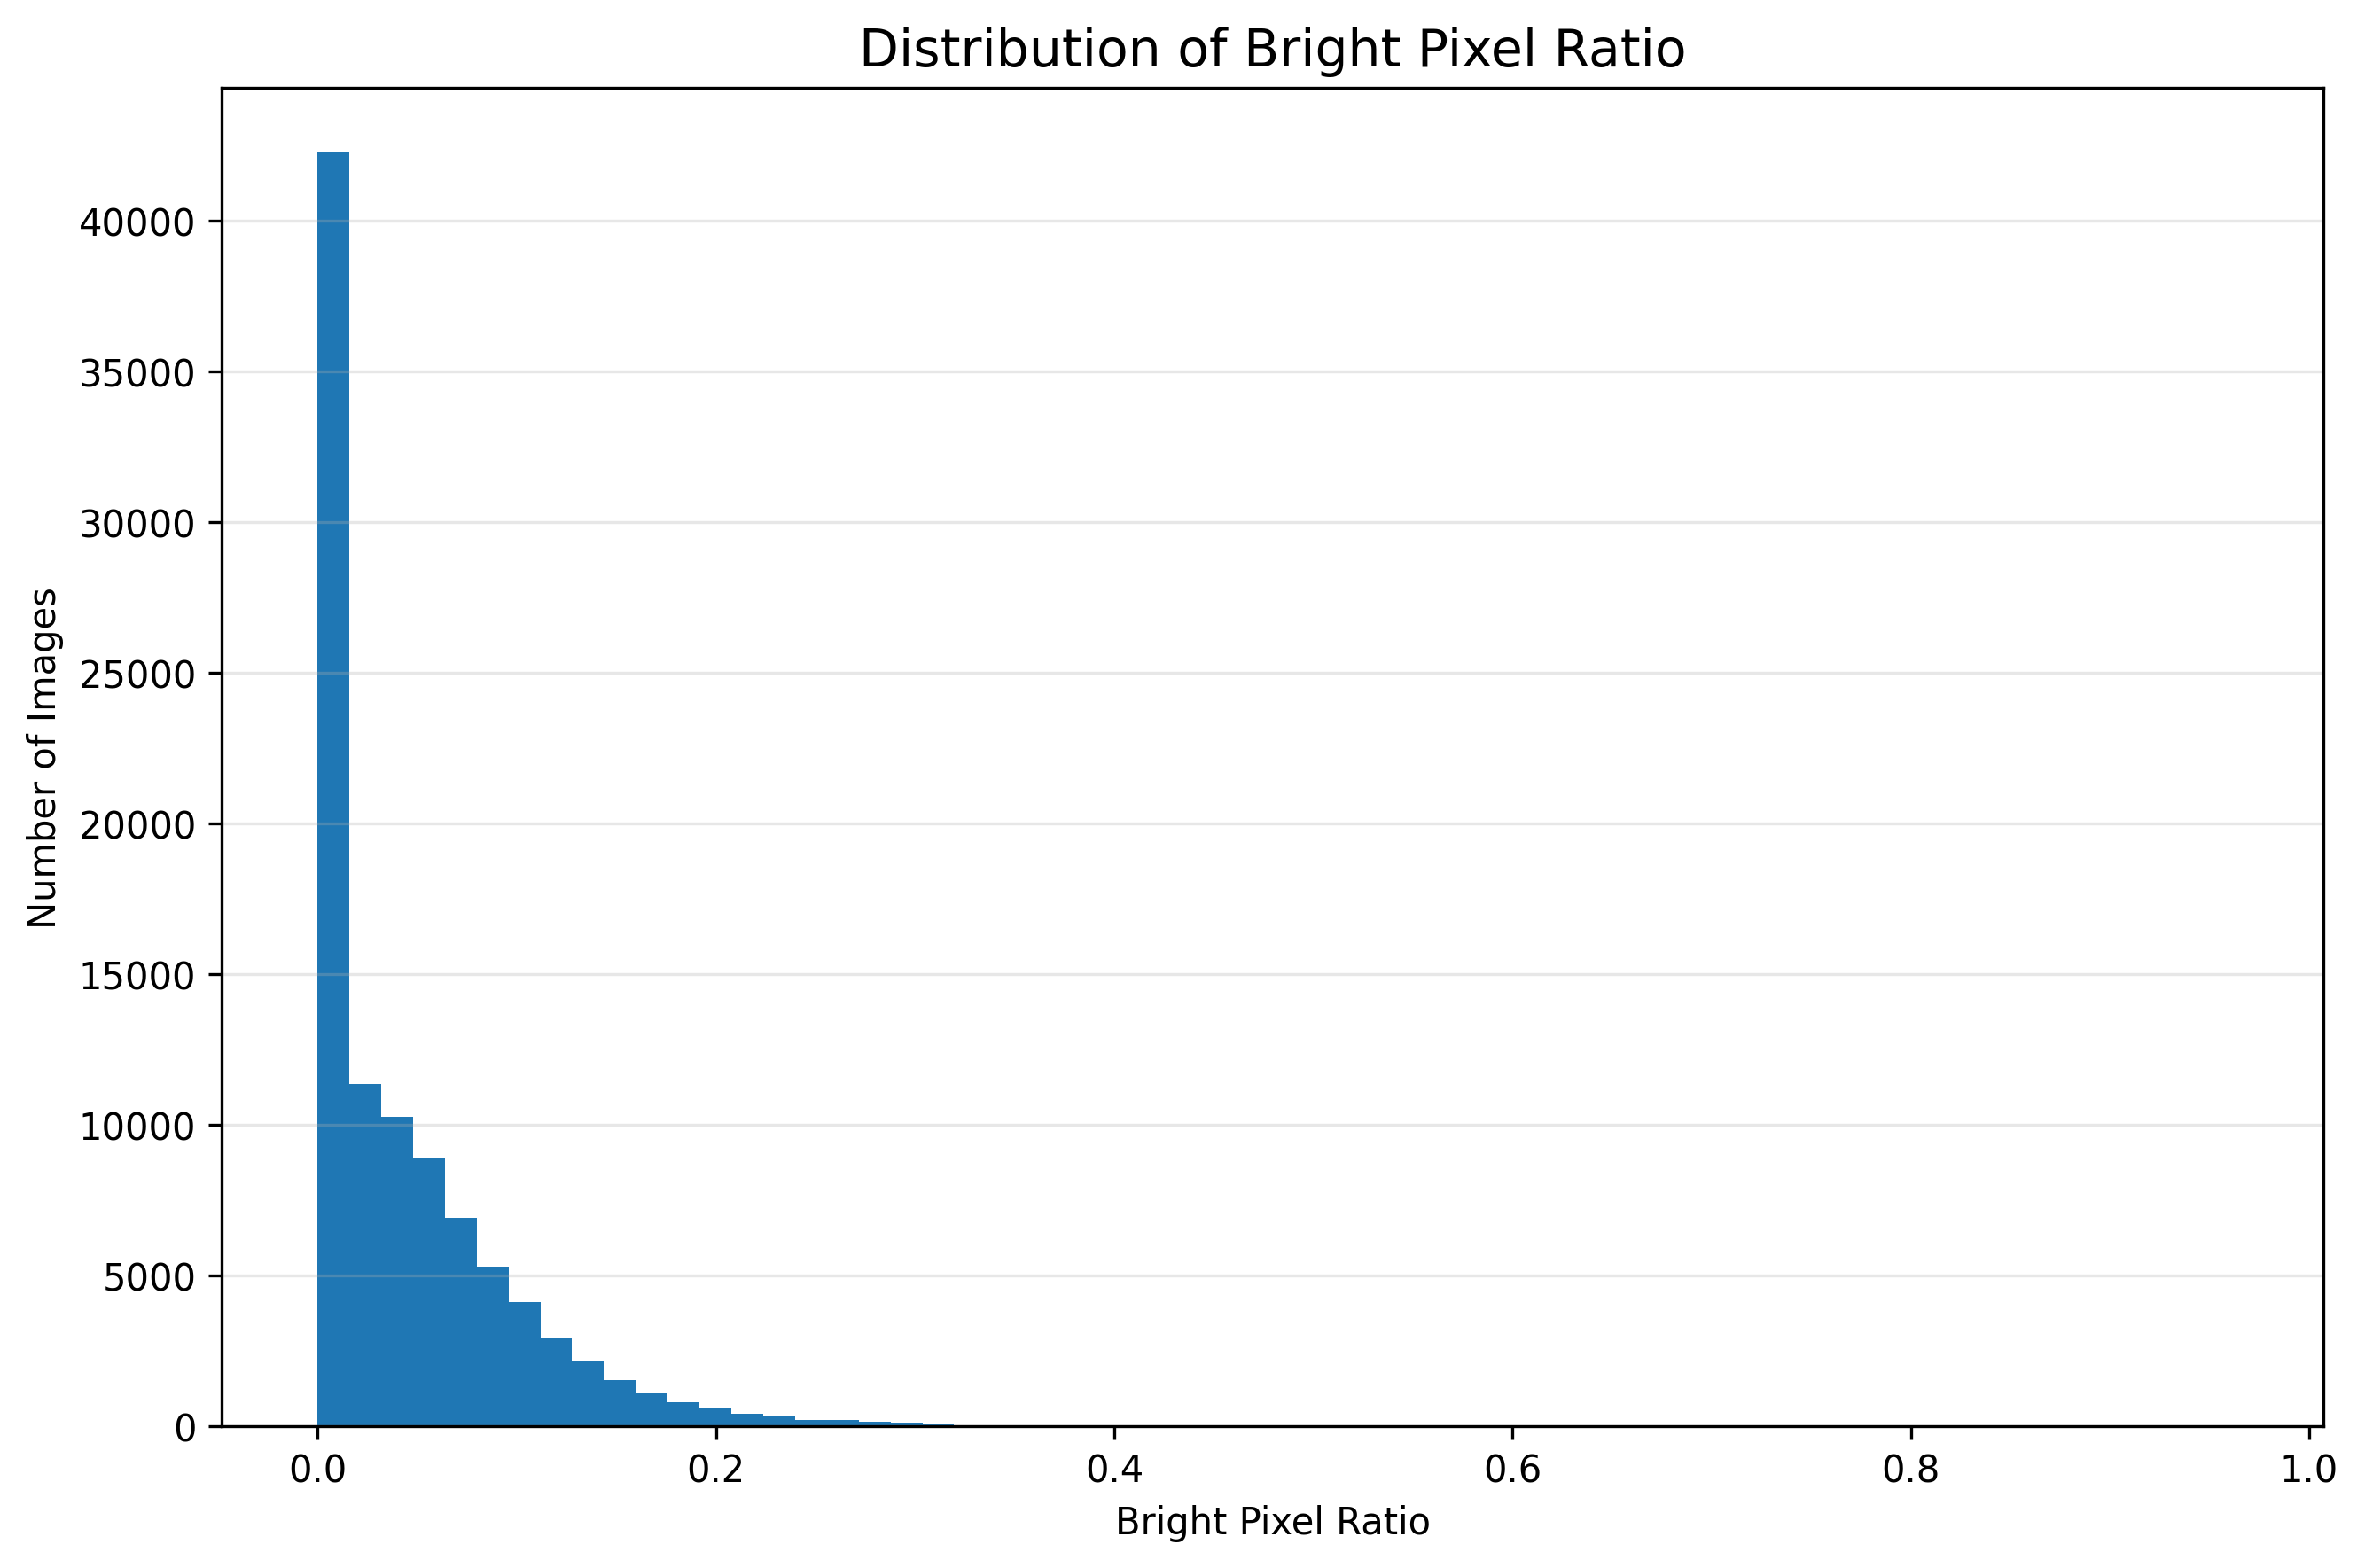

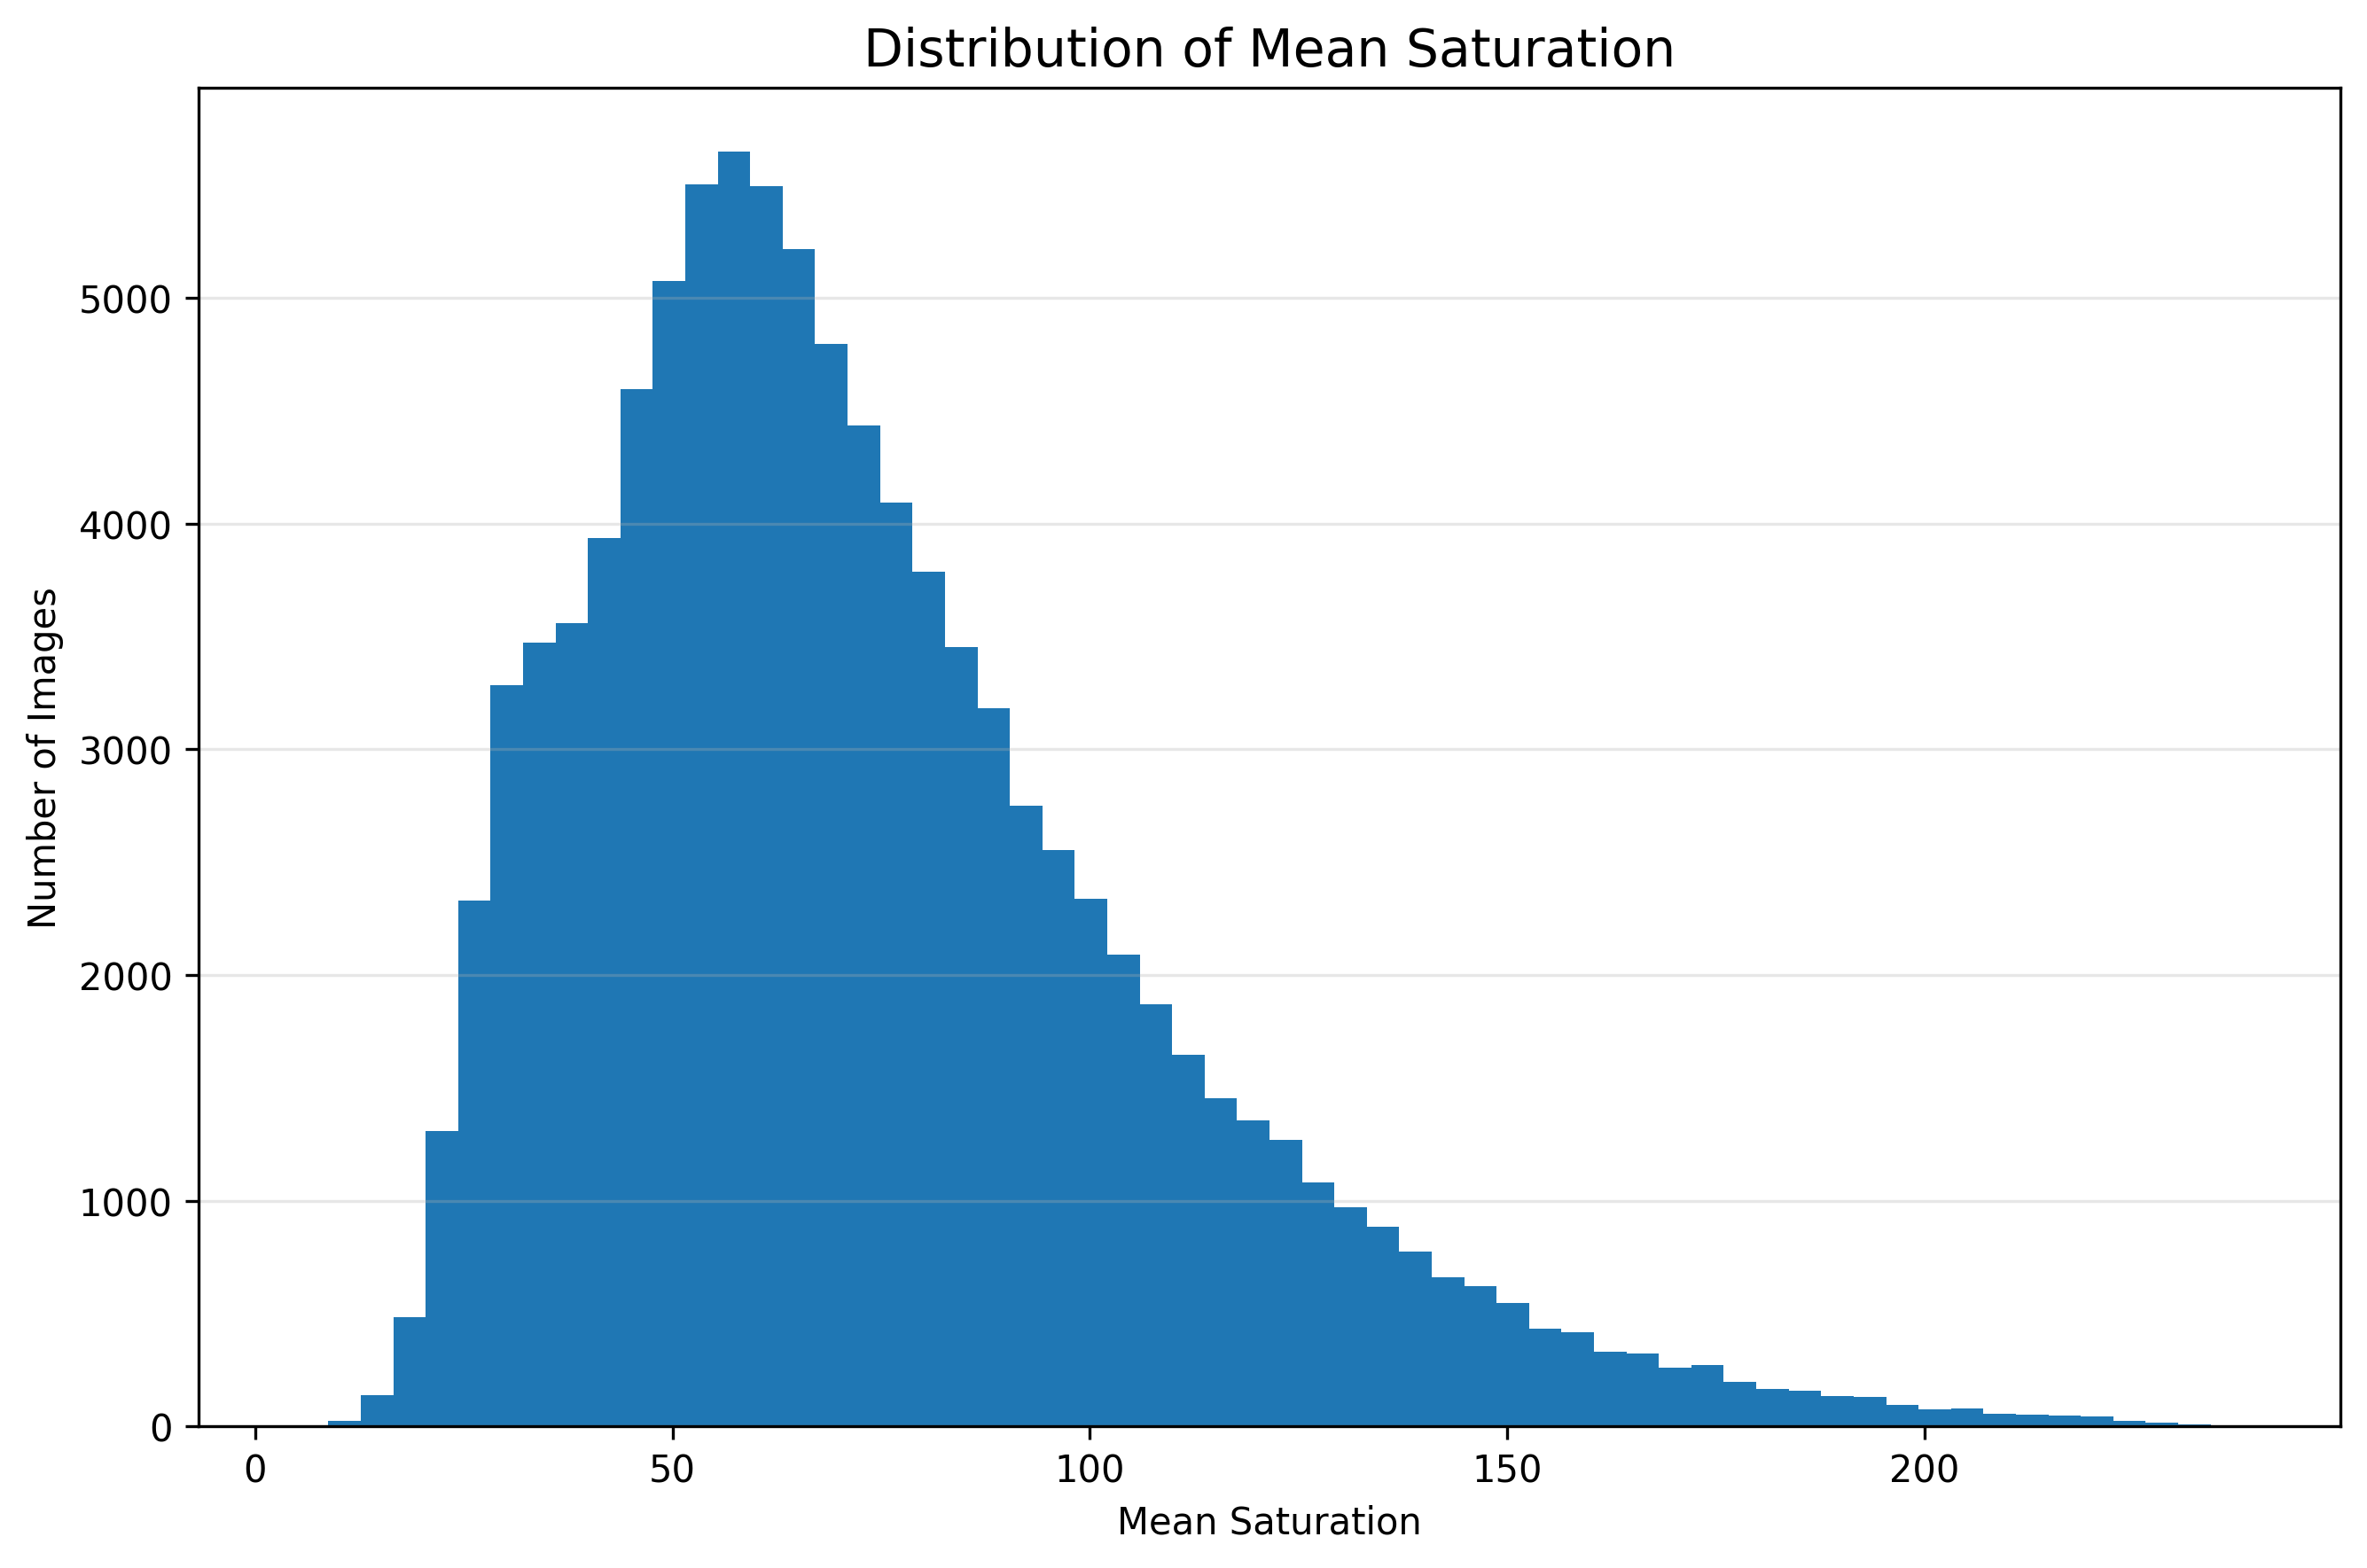

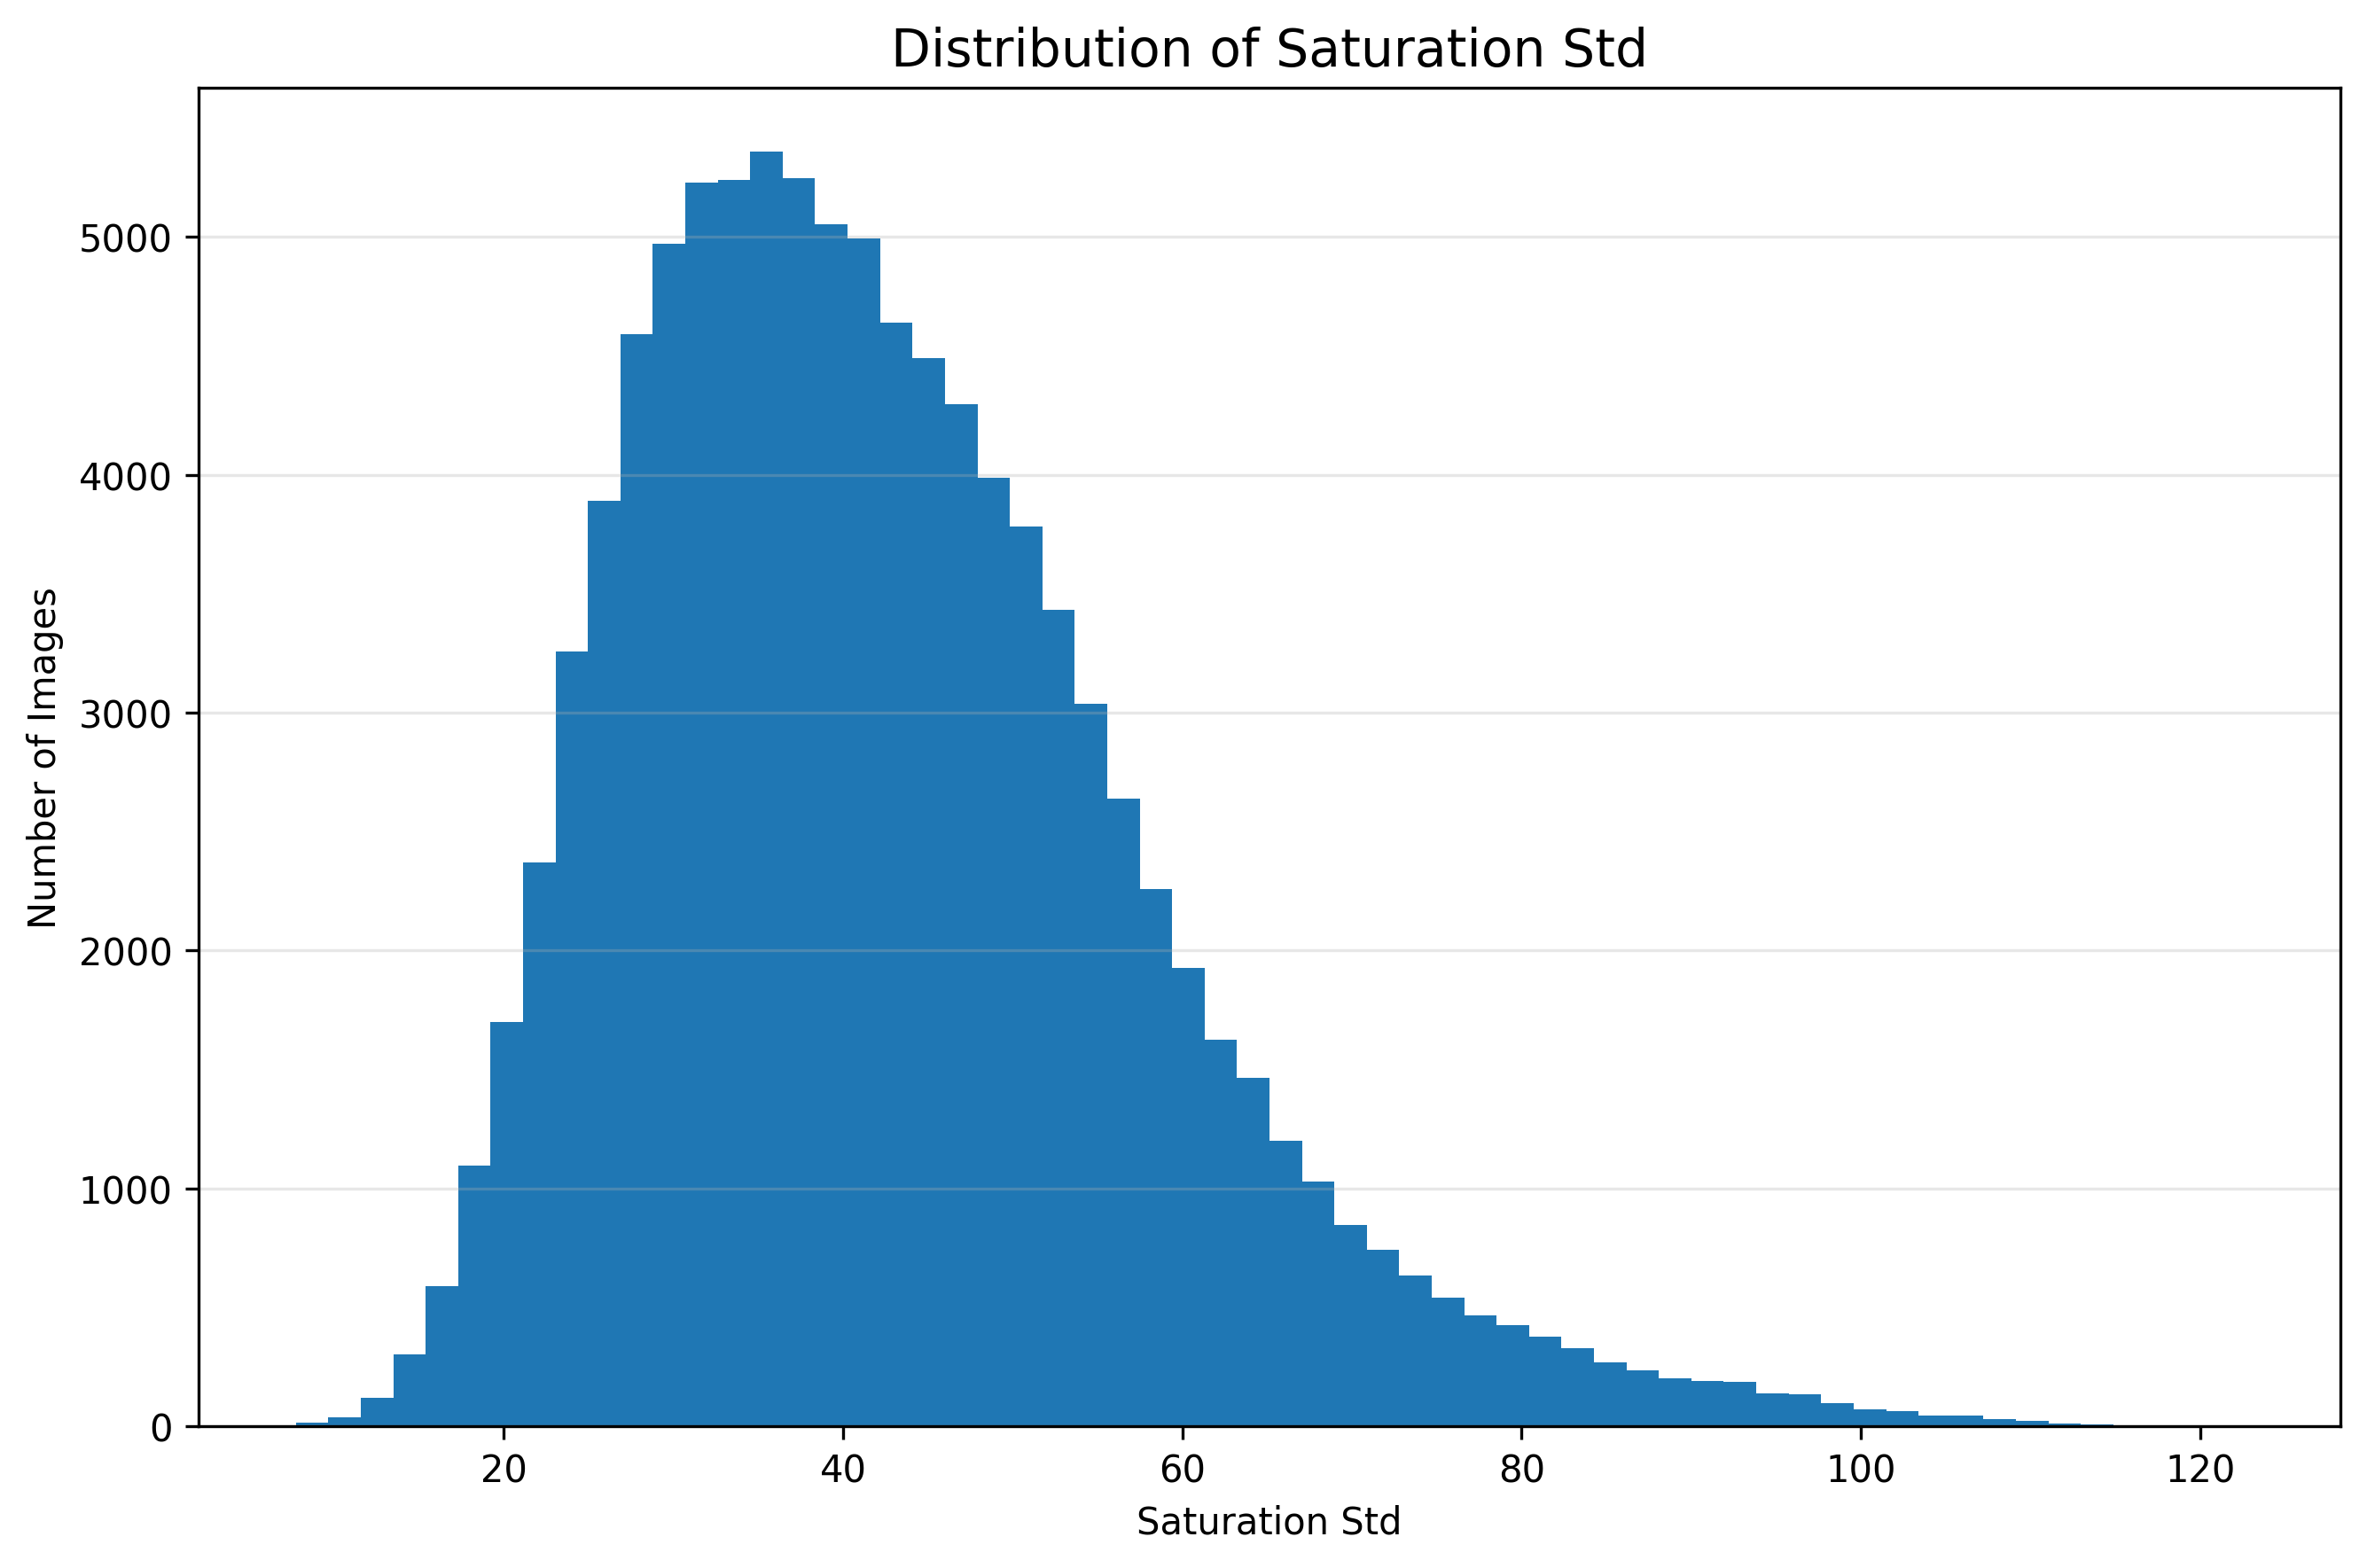

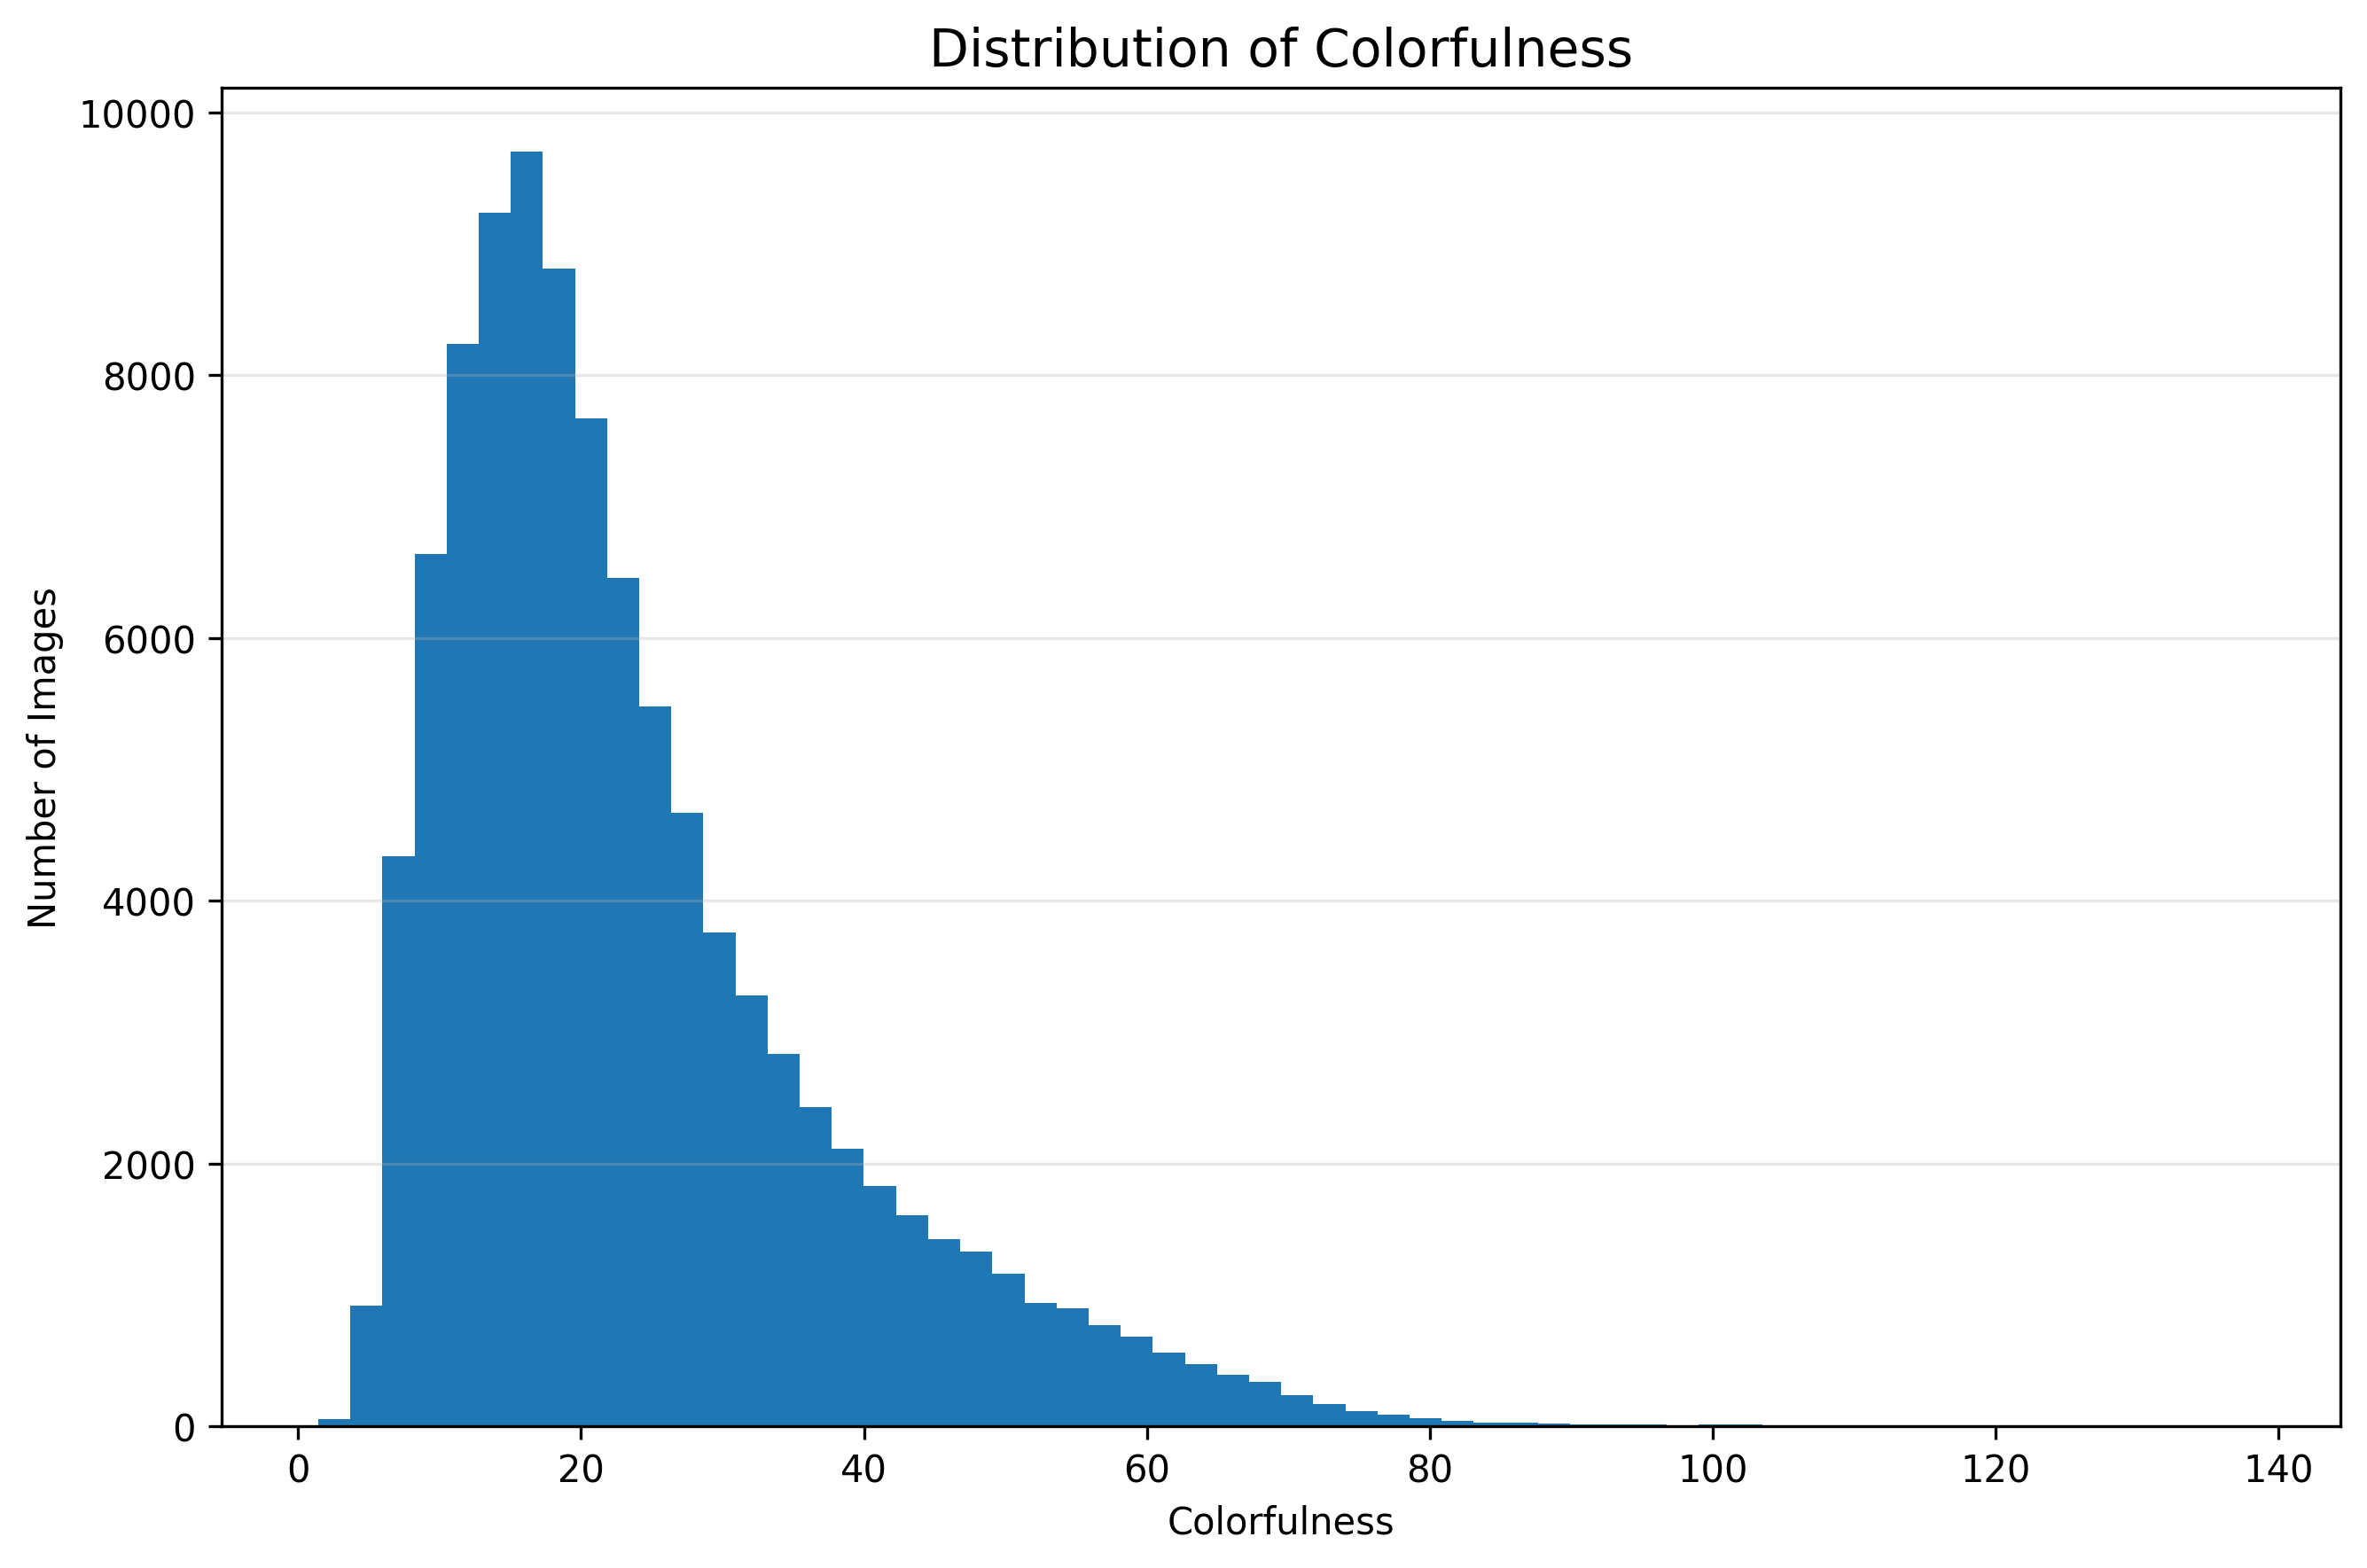

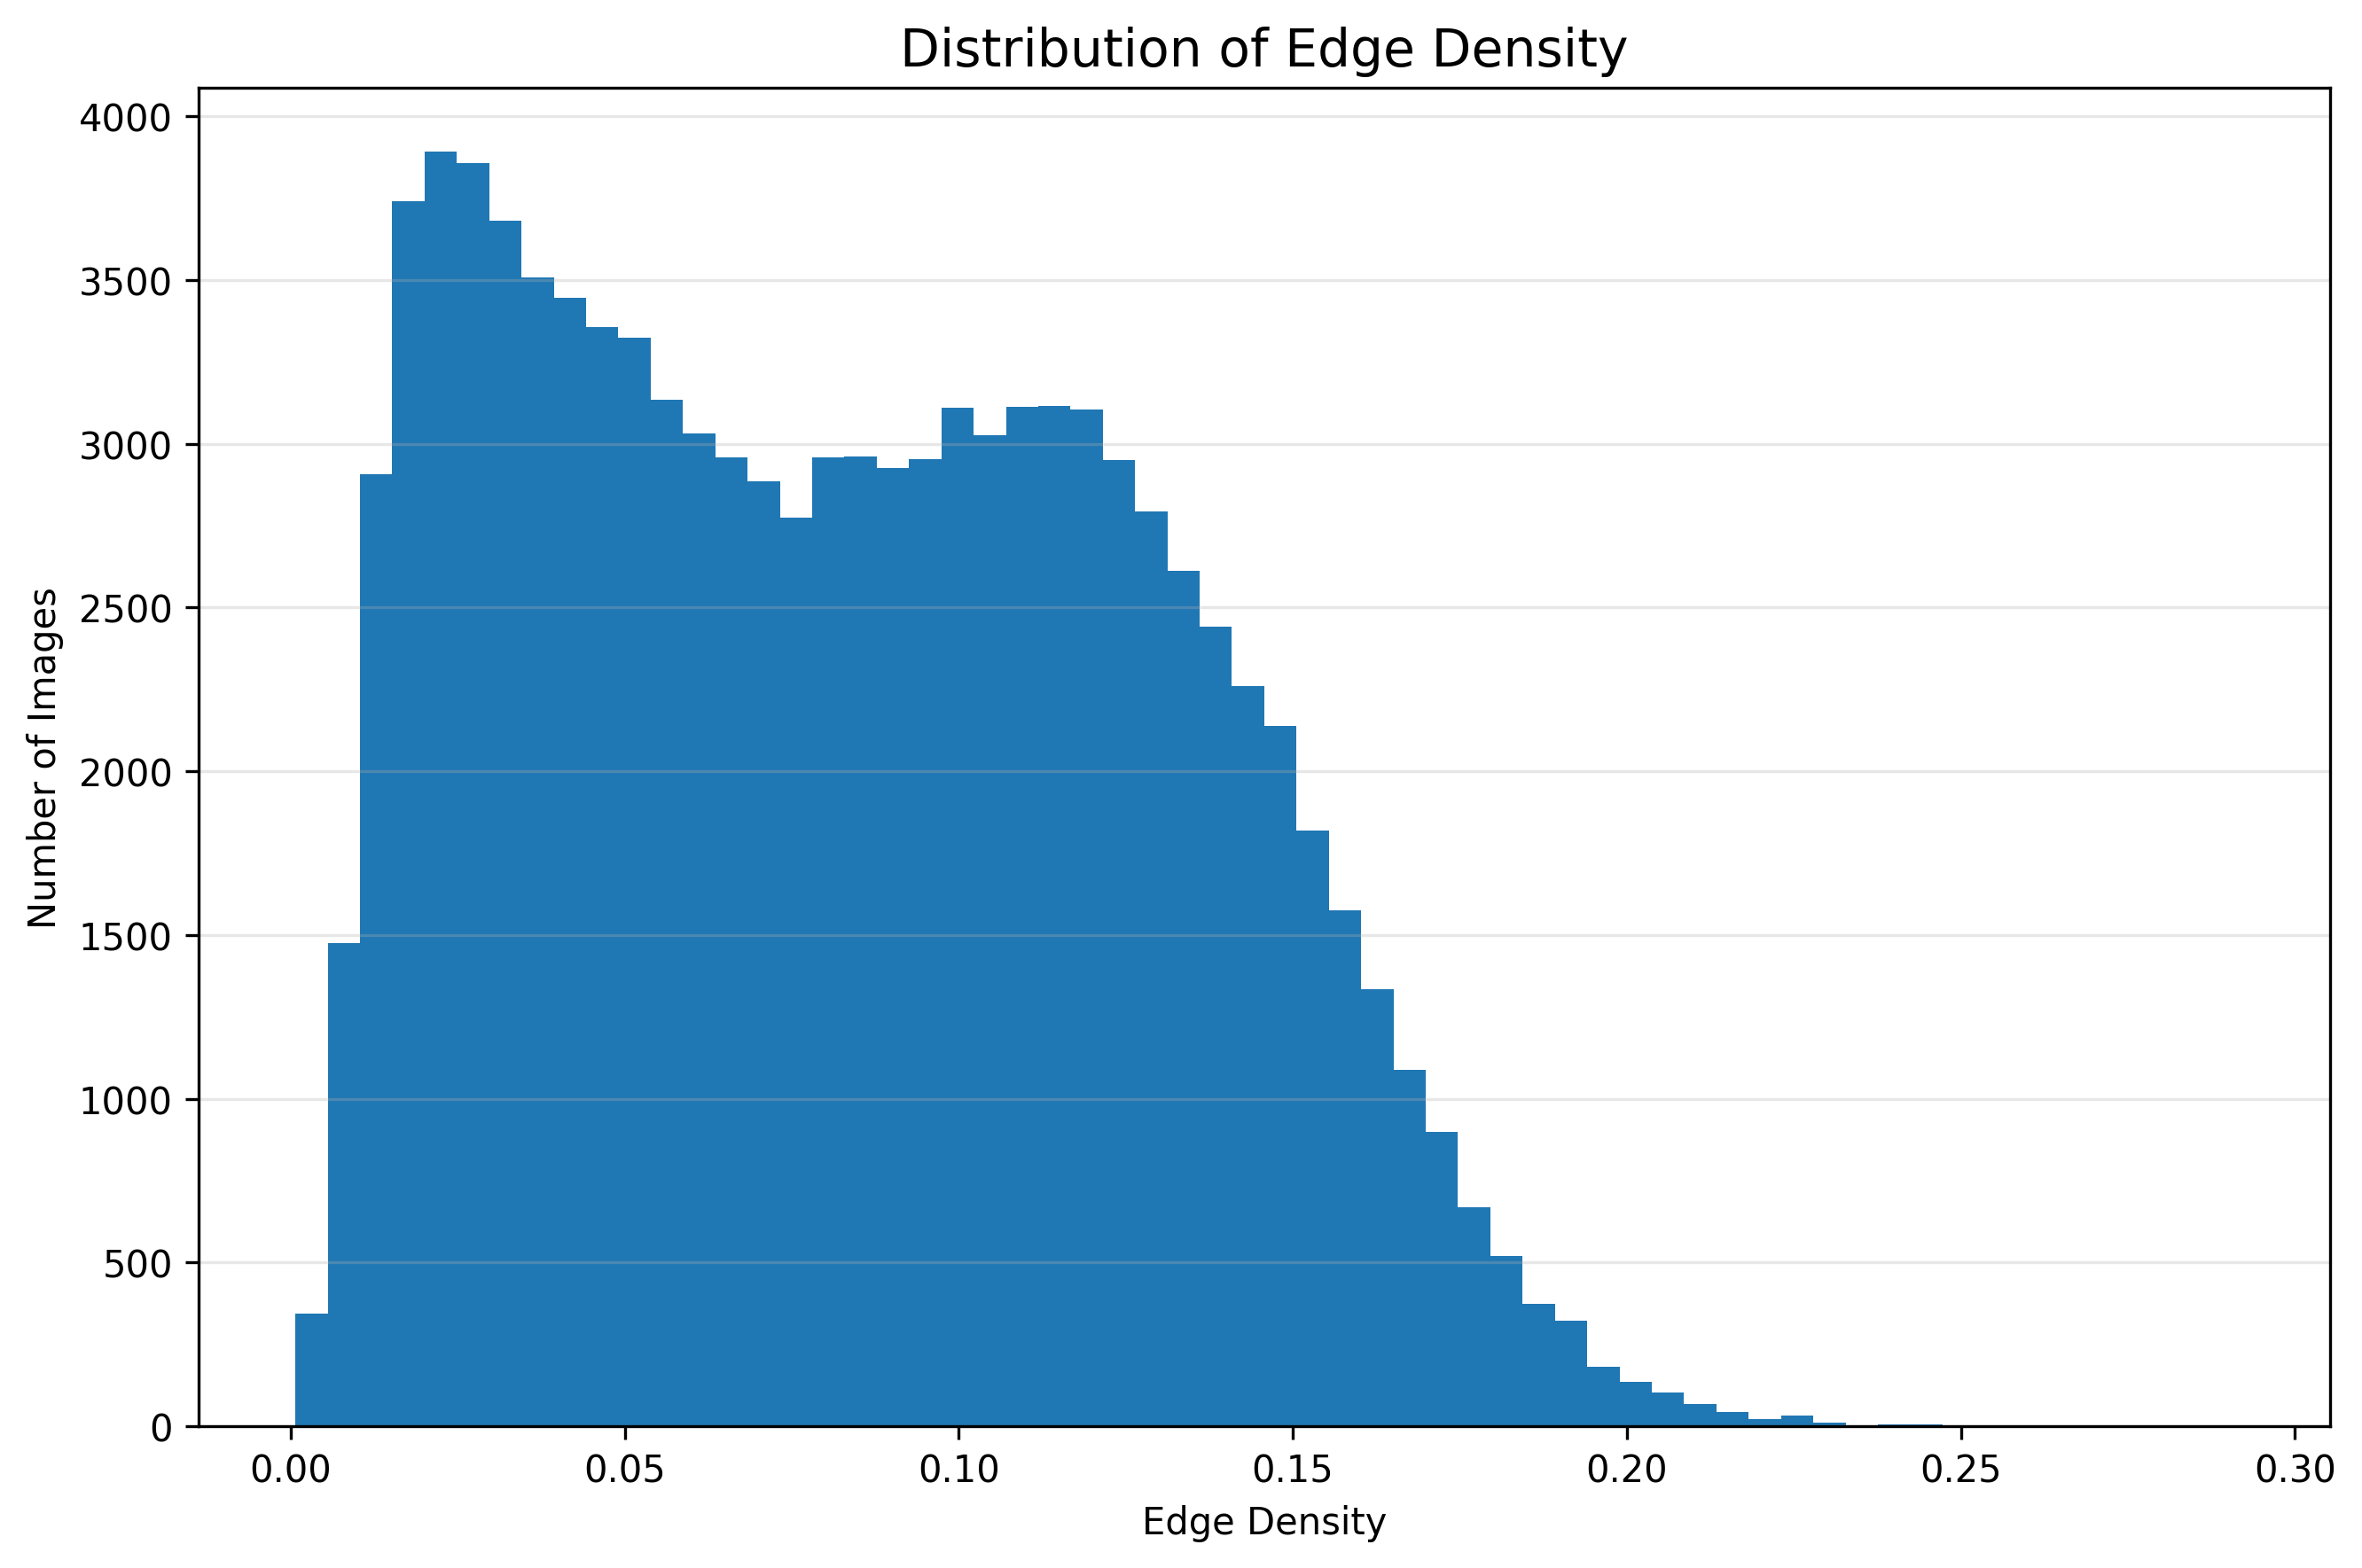

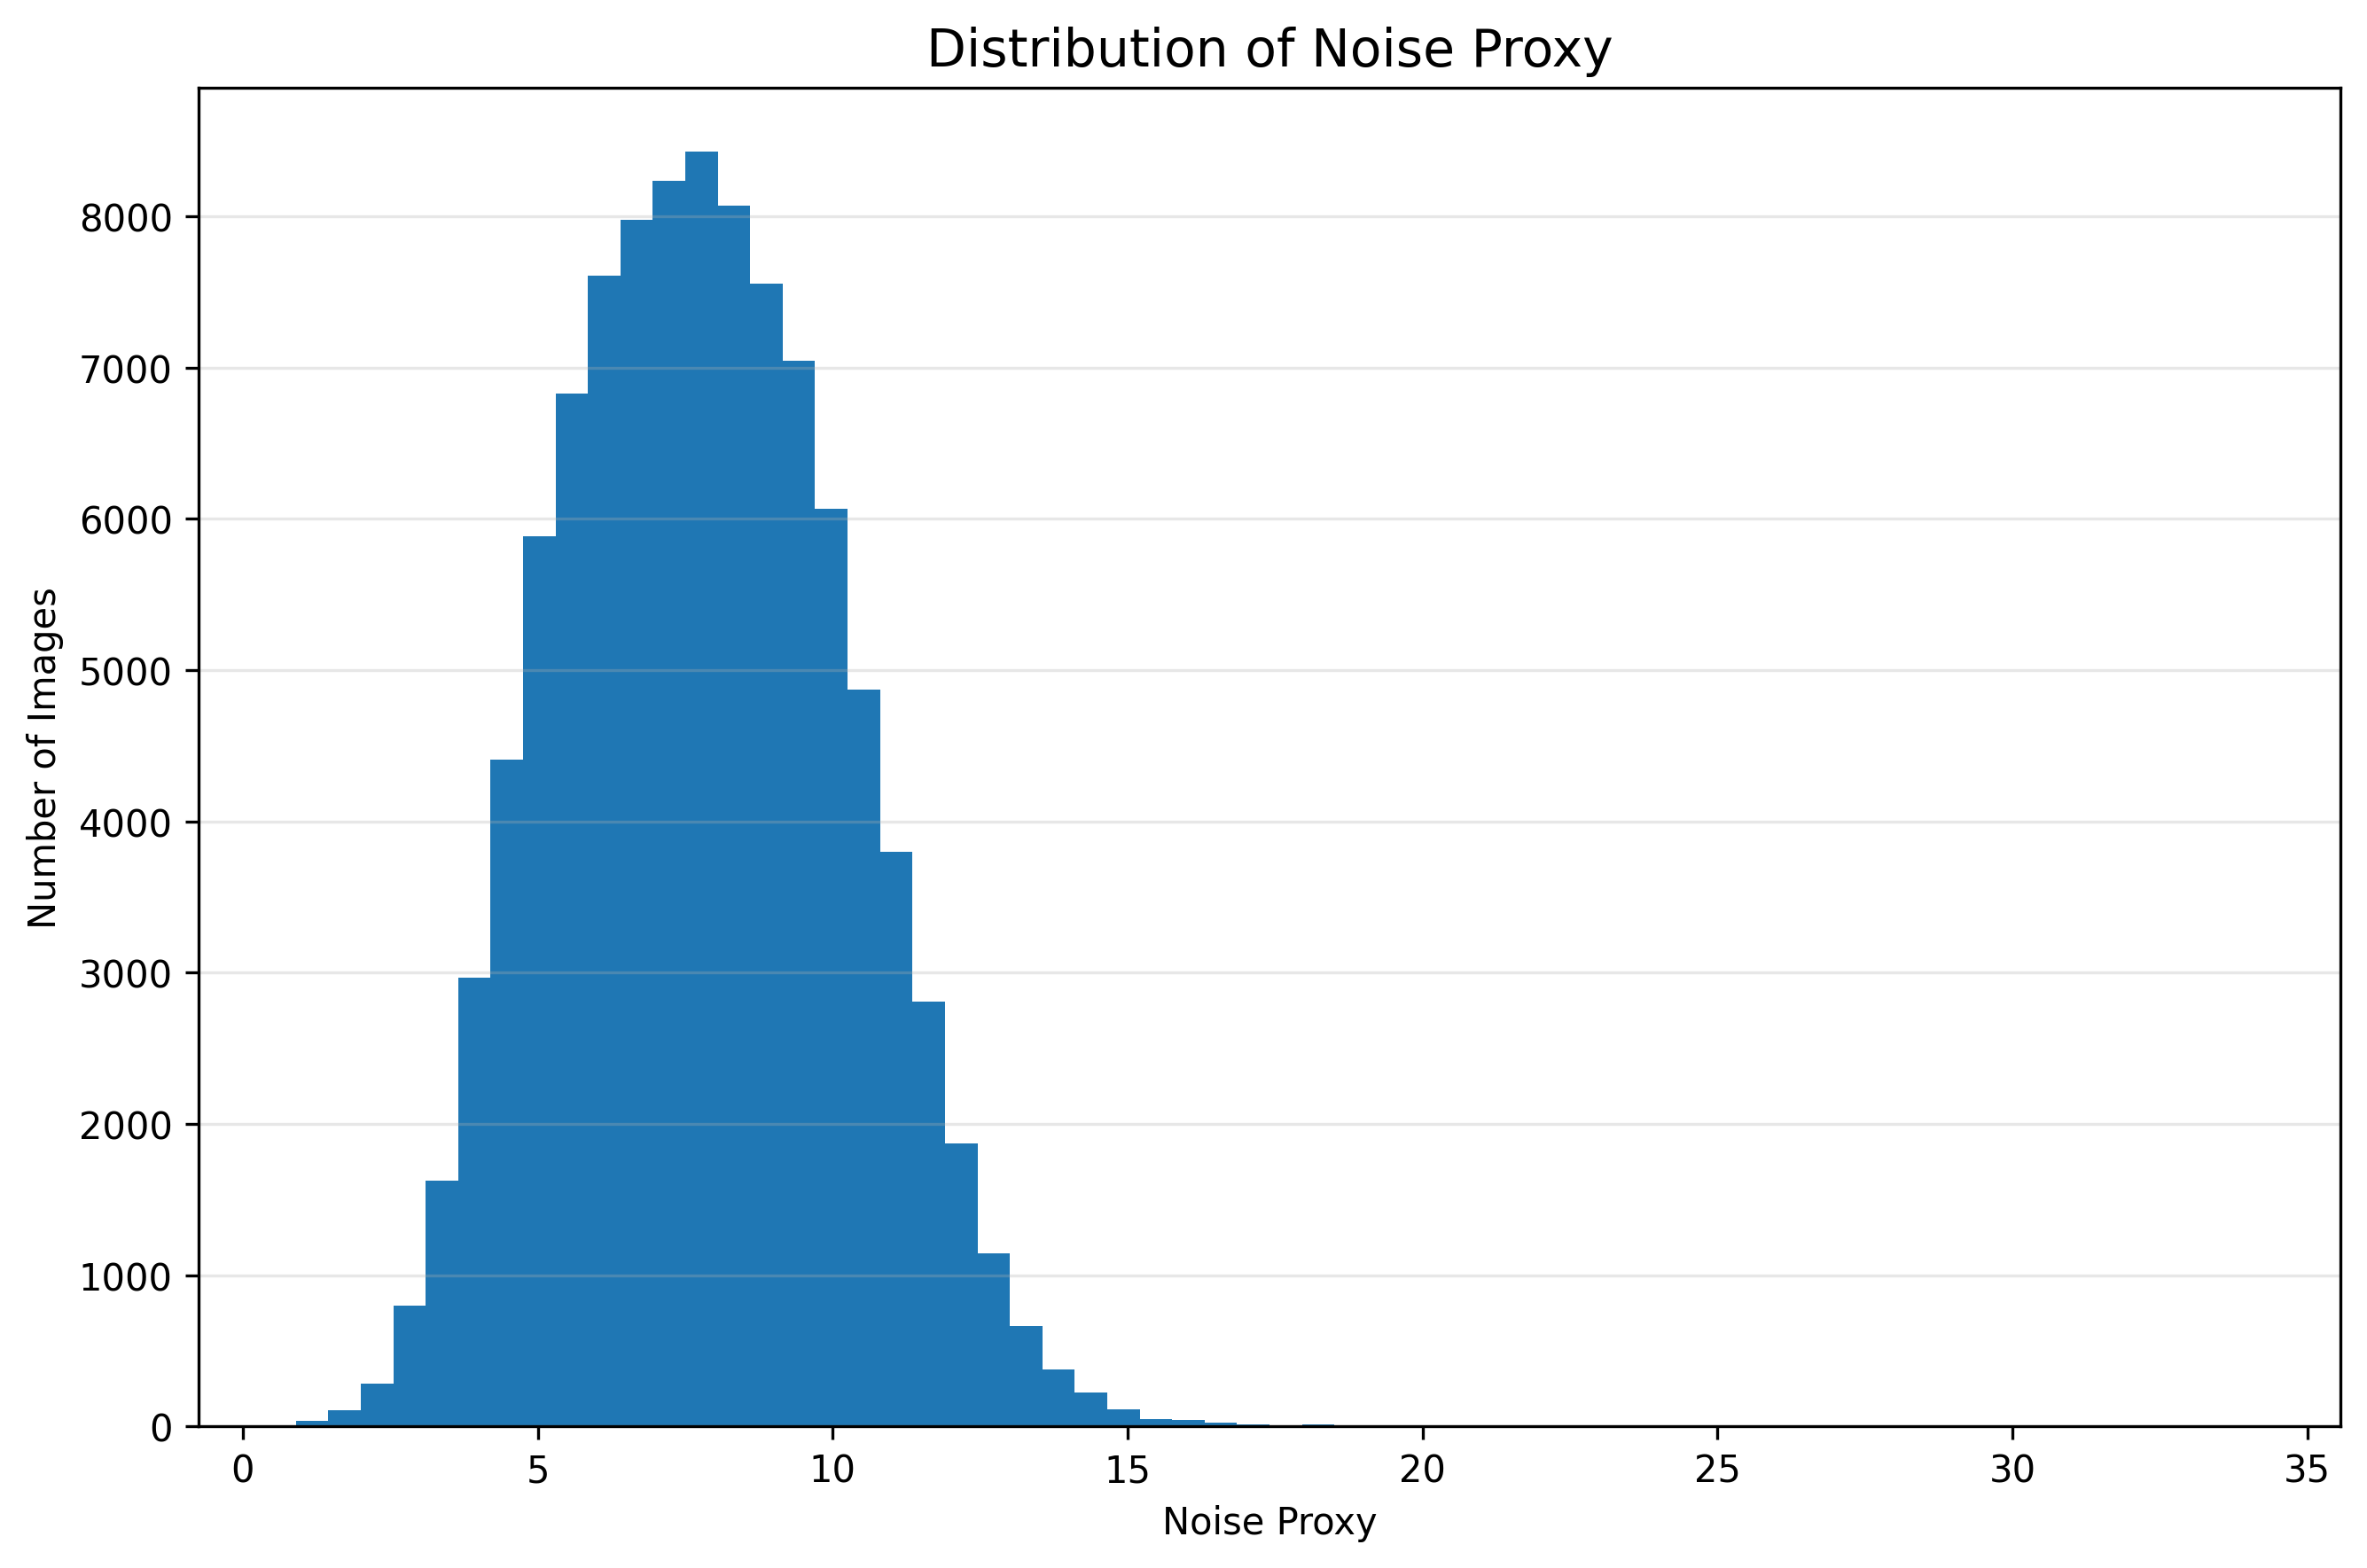


✓ IQA distribution figures generated.


In [13]:
for feature in IQA_FEATURES:

    plt.figure(
        figsize=(9, 6),
        dpi=300
    )

    plt.hist(
        iqa_features[feature],
        bins=60
    )

    plt.title(
        f"Distribution of {feature.replace('_', ' ').title()}",
        fontsize=14
    )

    plt.xlabel(
        feature.replace("_", " ").title()
    )

    plt.ylabel(
        "Number of Images"
    )

    plt.grid(
        axis="y",
        alpha=0.3
    )

    plt.tight_layout()

    figure_file = (
        FIGURES_PATH /
        f"iqa_{feature}.png"
    )

    plt.savefig(
        figure_file,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

print()
print("✓ IQA distribution figures generated.")

Save Final IQA Dataset

In [14]:
FIGURES_PATH = PROJECT_PATH / "figures"
FIGURES_PATH.mkdir(exist_ok=True)

final_iqa_file = (
    FIGURES_PATH /
    "iqa_features_all.csv"
)

iqa_features.to_csv(
    final_iqa_file,
    index=False
)

print("=" * 60)
print("Final IQA Dataset")
print("=" * 60)

print(
    f"Images  : {len(iqa_features):,}"
)

print(
    f"Columns : {len(iqa_features.columns)}"
)

print()

print(
    f"Saved to:\n{final_iqa_file}"
)

print()
print(
    "✓ Final IQA feature dataset saved successfully."
)

Final IQA Dataset
Images  : 100,000
Columns : 16

Saved to:
E:\ML_Project\figures\iqa_features_all.csv

✓ Final IQA feature dataset saved successfully.


Final Notebook 3 Summary

In [15]:
print("=" * 70)
print("NOTEBOOK 3 — IQA FEATURE EXTRACTION SUMMARY")
print("=" * 70)

print(
    f"Total Images Analyzed : "
    f"{len(iqa_features):,}"
)

print(
    f"IQA Features          : "
    f"{len(IQA_FEATURES)}"
)

print()

print("Extracted Feature Groups")
print("------------------------------")

print("• Brightness")
print("• Contrast")
print("• Sharpness / Blur")
print("• Entropy")
print("• Exposure")
print("• Color")
print("• Edge Density")
print("• Noise Proxy")

print()

print("Output Files")
print("------------------------------")

print("✓ iqa_features_train.csv")
print("✓ iqa_features_valid.csv")
print("✓ iqa_features_test.csv")
print("✓ iqa_features_all.csv")
print("✓ iqa_feature_statistics.csv")

print()

print("Overall Status")
print("------------------------------")

print(
    "✓ IQA feature extraction completed."
)

print(
    "✓ Feature validation completed."
)

print(
    "✓ IQA dataset prepared for subsequent analysis."
)

NOTEBOOK 3 — IQA FEATURE EXTRACTION SUMMARY
Total Images Analyzed : 100,000
IQA Features          : 13

Extracted Feature Groups
------------------------------
• Brightness
• Contrast
• Sharpness / Blur
• Entropy
• Exposure
• Color
• Edge Density
• Noise Proxy

Output Files
------------------------------
✓ iqa_features_train.csv
✓ iqa_features_valid.csv
✓ iqa_features_test.csv
✓ iqa_features_all.csv
✓ iqa_feature_statistics.csv

Overall Status
------------------------------
✓ IQA feature extraction completed.
✓ Feature validation completed.
✓ IQA dataset prepared for subsequent analysis.
